# IF3270 Pembelajaran Mesin — Tugas Besar 1
## FFNN From Scratch: Global Student Placement & Salary


## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from utils import (
    run_architecture_experiments,
    run_learning_rate_experiments,
    plot_train_val_curves,
    plot_prediction_bars,
    analyze_results_distributions,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load and Explore the Dataset

In [2]:
DATA_PATH = '../data/student_placement_salary.csv'

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
df.describe()

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

Missing values:
 cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64


,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [4]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)


college_tier:
college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
----------------------------------------

country:
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
----------------------------------------

university_ranking_band:
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
----------------------------------------

specialization:
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
----------------------------------------

industry:
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
----------------------------------------

placement_status:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
--

## 3. Data Preprocessing

In [5]:
TARGET_COL  = 'placement_status'   

df = df.dropna(subset=[TARGET_COL])

# 2. Encode categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

label_cols = ['college_tier', 'university_ranking_band']
ohe_cols = [o for o in cat_cols if o not in label_cols]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# 3. Encode target
y_raw = le.fit_transform(df[TARGET_COL].astype(str))
n_classes = len(np.unique(y_raw))

if n_classes == 2:
    # Binary classification → sigmoid + BCE
    y = y_raw.reshape(-1, 1).astype(float)
    TASK = 'binary'
else:
    # Multi-class → softmax + CCE (one-hot)
    y = np.eye(n_classes)[y_raw]
    TASK = 'multiclass'

print(f"Task: {TASK}, classes: {n_classes}, y shape: {y.shape}")

# 4. Feature matrix
X_df = df.drop(columns=[TARGET_COL])
X_df = X_df.select_dtypes(include=[np.number]).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X_df.values).astype(float)
print(f"X shape: {X.shape}")

# 5. Train / validation / test split  (60 / 20 / 20)
X_tmp,  X_test,  y_tmp,  y_test  = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Task: binary, classes: 2, y shape: (10000, 1)
X shape: (10000, 8)
Train: (6000, 8), Val: (2000, 8), Test: (2000, 8)


## 4. Model Testing


### 4.1 Hyperparameter

#### 4.1.1 Depth and Width Parameter

In [6]:
n_features = X_train.shape[1]
n_out      = y_train.shape[1]

experiments = {
    # Width Variations (depth = 2 tetap)
    'Width_Small': [
        {'n_in': n_features,  'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': 16, 'activation': 'relu'},
        {'n_in': 16, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Medium': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 32, 'activation': 'relu'},
        {'n_in': 32, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Width_Large': [
        {'n_in': n_features,   'n_out': 128, 'activation': 'relu'},
        {'n_in': 128, 'n_out': 64,  'activation': 'relu'},
        {'n_in': 64,  'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    
    # Depth Variations (width = 64 tetap)
    'Depth_1': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_2': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
    'Depth_3': [
        {'n_in': n_features,  'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
    ],
}


In [ ]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

results = run_architecture_experiments(
    experiments=experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Width_Small
  Layer 1: DenseLayer(8 → 32, activation=ReLU)  [288 params]
  Layer 2: DenseLayer(32 → 16, activation=ReLU)  [528 params]
  Layer 3: DenseLayer(16 → 1, activation=Sigmoid)  [17 params]
----------------------------------------------------
  Total params: 833
Epoch 10/200, Train Loss: 0.5411, Val Loss: 0.5310
Epoch 20/200, Train Loss: 0.5078, Val Loss: 0.5027
Epoch 30/200, Train Loss: 0.5003, Val Loss: 0.4988
Epoch 40/200, Train Loss: 0.4957, Val Loss: 0.4950
Epoch 50/200, Train Loss: 0.4932, Val Loss: 0.4940
Epoch 60/200, Train Loss: 0.4931, Val Loss: 0.4940
Epoch 70/200, Train Loss: 0.4914, Val Loss: 0.4945
Epoch 80/200, Train Loss: 0.4915, Val Loss: 0.4949
Epoch 90/200, Train Loss: 0.4904, Val Loss: 0.4955
Epoch 100/200, Train Loss: 0.4902, Val Loss: 0.4960
Epoch 110/200, Train Loss: 0.4901, Val Loss: 0.4982
Epoch 120/200, Train Loss: 0.4893, Val Loss: 0.4980
Epoch 130/200, Train Loss: 0.4895, Val Loss: 0.4981
Epoch 140/200, Train Loss: 0.4891, Val Loss: 0.5010


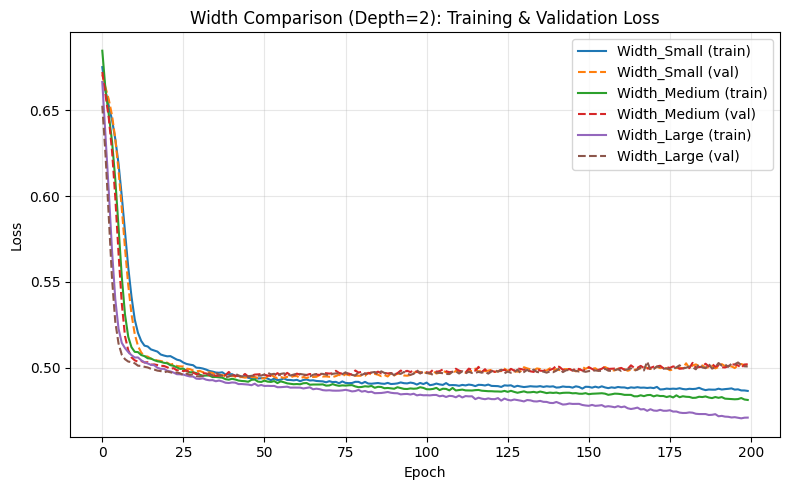

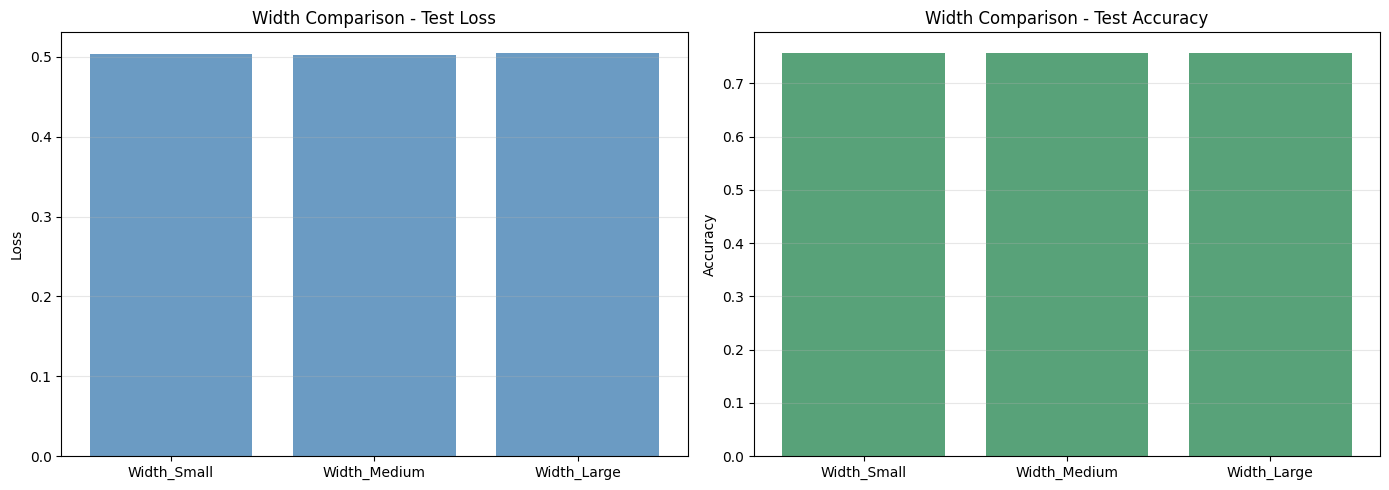

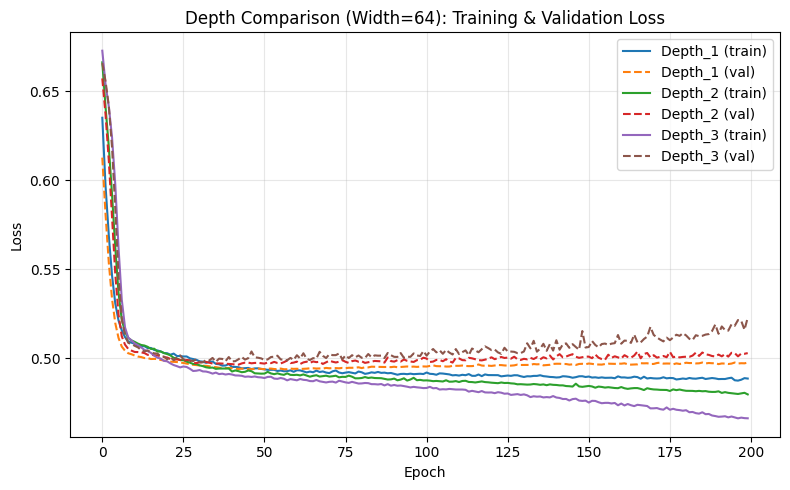

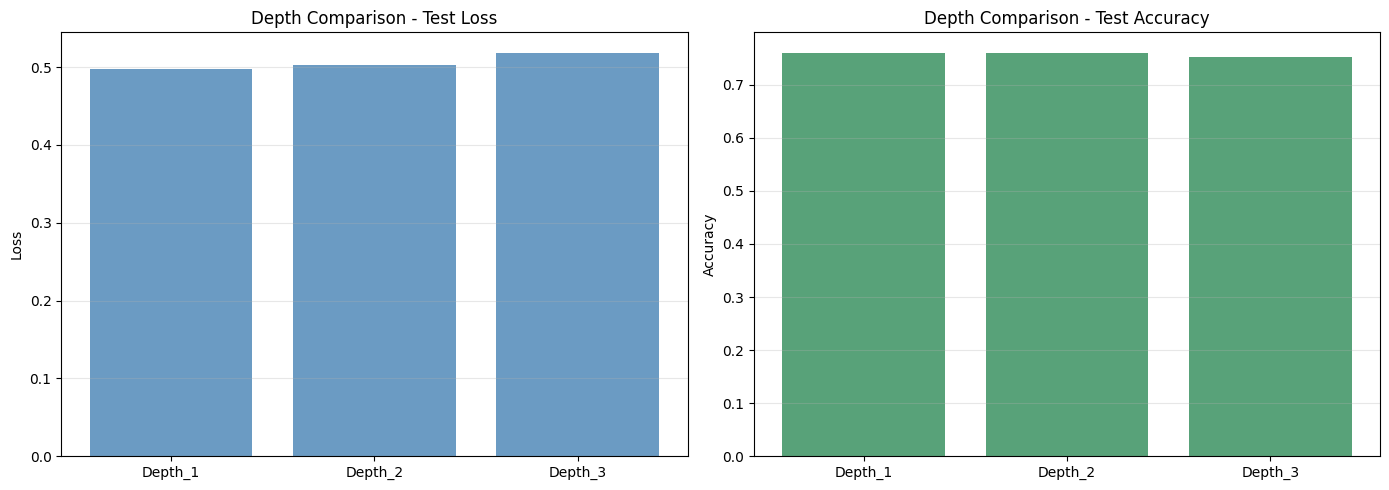

In [ ]:
width_results = {k: results[k] for k in ['Width_Small', 'Width_Medium', 'Width_Large']}
depth_results = {k: results[k] for k in ['Depth_1', 'Depth_2', 'Depth_3']}

plot_train_val_curves(
    width_results,
    title='Width Comparison (Depth=2): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    width_results,
    title_prefix='Width Comparison',
)

plot_train_val_curves(
    depth_results,
    title='Depth Comparison (Width=64): Training & Validation Loss',
    zoom_start=50,
)
plot_prediction_bars(
    depth_results,
    title_prefix='Depth Comparison',
)

### 4.1.2 Fungsi Aktivasi

In [ ]:
BASE_ARCH = [128, 64]

activation_functions = ['linear', 'relu', 'sigmoid', 'tanh']

activation_experiments = {}

for act_name in activation_functions:
    config = []
    
    # Hidden Layer 1
    config.append({
        'n_in': n_features,
        'n_out': BASE_ARCH[0],
        'activation': act_name
    })
    
    # Hidden Layer 2
    config.append({
        'n_in': BASE_ARCH[0],
        'n_out': BASE_ARCH[1],
        'activation': act_name 
    })
    
    # Output Layer
    config.append({
        'n_in': BASE_ARCH[1],
        'n_out': n_out,
        'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'
    })
    
    activation_experiments[f'Act_{act_name.capitalize()}'] = config

print("Activation Function Experiments:")
for name, config in activation_experiments.items():
    hidden_act = config[0]['activation']
    print(f"  {name}: Hidden layers use '{hidden_act}' activation")

Activation Function Experiments:
  Act_Linear: Hidden layers use 'linear' activation
  Act_Relu: Hidden layers use 'relu' activation
  Act_Sigmoid: Hidden layers use 'sigmoid' activation
  Act_Tanh: Hidden layers use 'tanh' activation


In [ ]:
INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

activation_results = run_architecture_experiments(
    experiments=activation_experiments,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    lr=0.01,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: Act_Linear
  Layer 1: DenseLayer(8 → 128, activation=Linear)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=Linear)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5123, Val Loss: 0.5026
Epoch 20/200, Train Loss: 0.5119, Val Loss: 0.5021
Epoch 30/200, Train Loss: 0.5125, Val Loss: 0.5028
Epoch 40/200, Train Loss: 0.5118, Val Loss: 0.5025
Epoch 50/200, Train Loss: 0.5118, Val Loss: 0.5022
Epoch 60/200, Train Loss: 0.5127, Val Loss: 0.5025
Epoch 70/200, Train Loss: 0.5119, Val Loss: 0.5030
Epoch 80/200, Train Loss: 0.5118, Val Loss: 0.5027
Epoch 90/200, Train Loss: 0.5120, Val Loss: 0.5029
Epoch 100/200, Train Loss: 0.5119, Val Loss: 0.5029
Epoch 110/200, Train Loss: 0.5116, Val Loss: 0.5022
Epoch 120/200, Train Loss: 0.5121, Val Loss: 0.5026
Epoch 130/200, Train Loss: 0.5121, Val Loss: 0.5022
Epoch 140/200, Train Loss: 0.5122, Val Lo

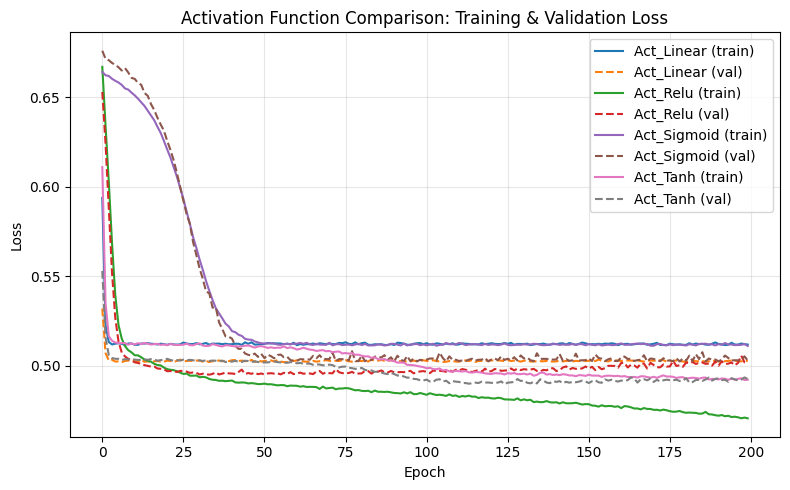

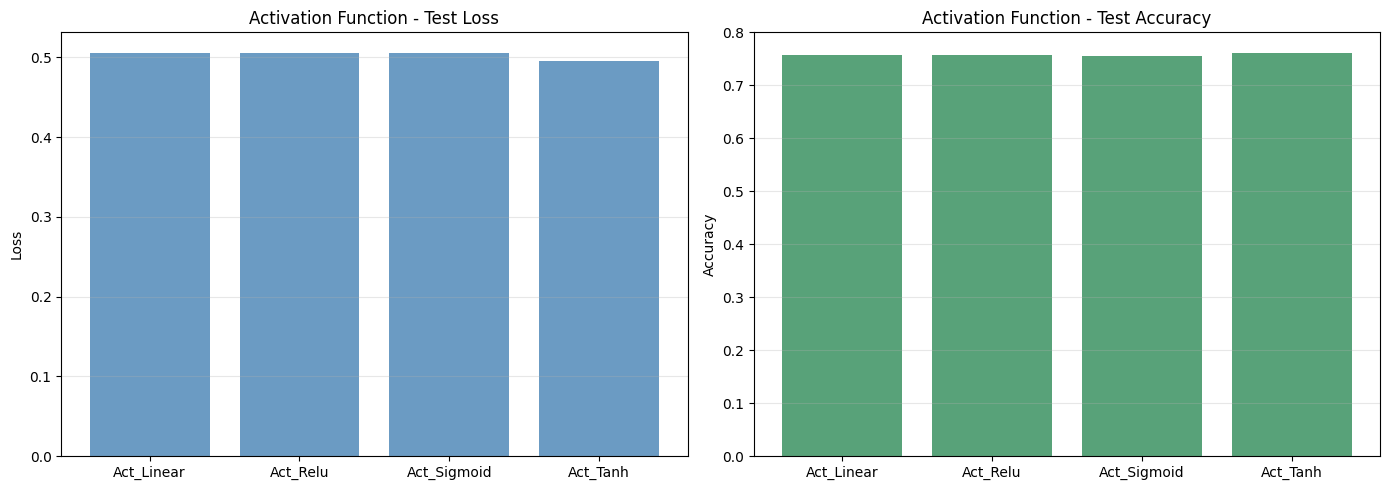

In [ ]:
plot_train_val_curves(
    activation_results,
    title='Activation Function Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    activation_results,
    title_prefix='Activation Function',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Linear
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003985 | Std: 0.100151
  Min: -0.359808 | Max: 0.326939
  Median: -0.001782

Layer 1:
  Shape: (128, 64)
  Mean: -0.000755 | Std: 0.100453
  Min: -0.442598 | Max: 0.405982
  Median: -0.000586

Layer 2:
  Shape: (64, 1)
  Mean: 0.001172 | Std: 0.100374
  Min: -0.229550 | Max: 0.243466
  Median: 0.001499

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000327 | Std: 0.006088
  Min: -0.038911 | Max: 0.030023
  Median: 0.000163
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

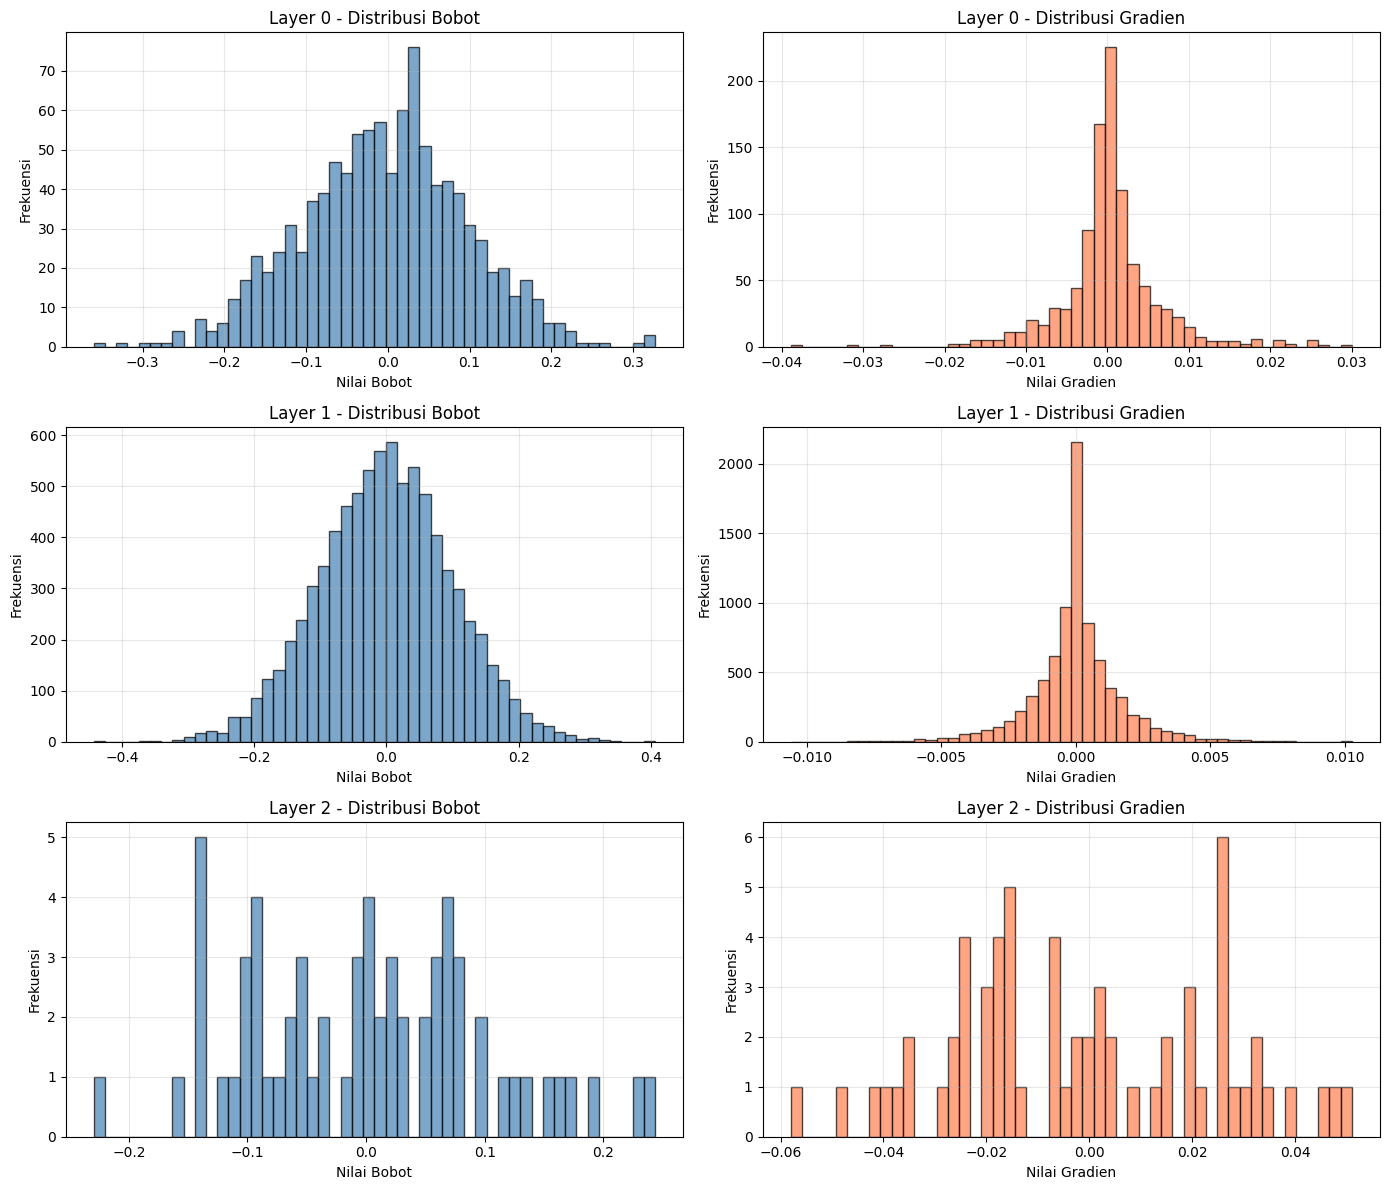


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Relu
Test Accuracy: 0.7565

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001484 | Std: 0.125161
  Min: -0.394423 | Max: 0.545343
  Median: 0.003148

Layer 1:
  Shape: (128, 64)
  Mean: 0.001577 | Std: 0.103948
  Min: -0.439155 | Max: 0.419099
  Median: 0.001555

Layer 2:
  Shape: (64, 1)
  Mean: 0.032919 | Std: 0.309648
  Min: -0.622051 | Max: 0.710821
  Median: 0.034440

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000285 | Std: 0.023630
  Min: -0.123074 | Max: 0.131426
  Median: 0.000075
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128, 

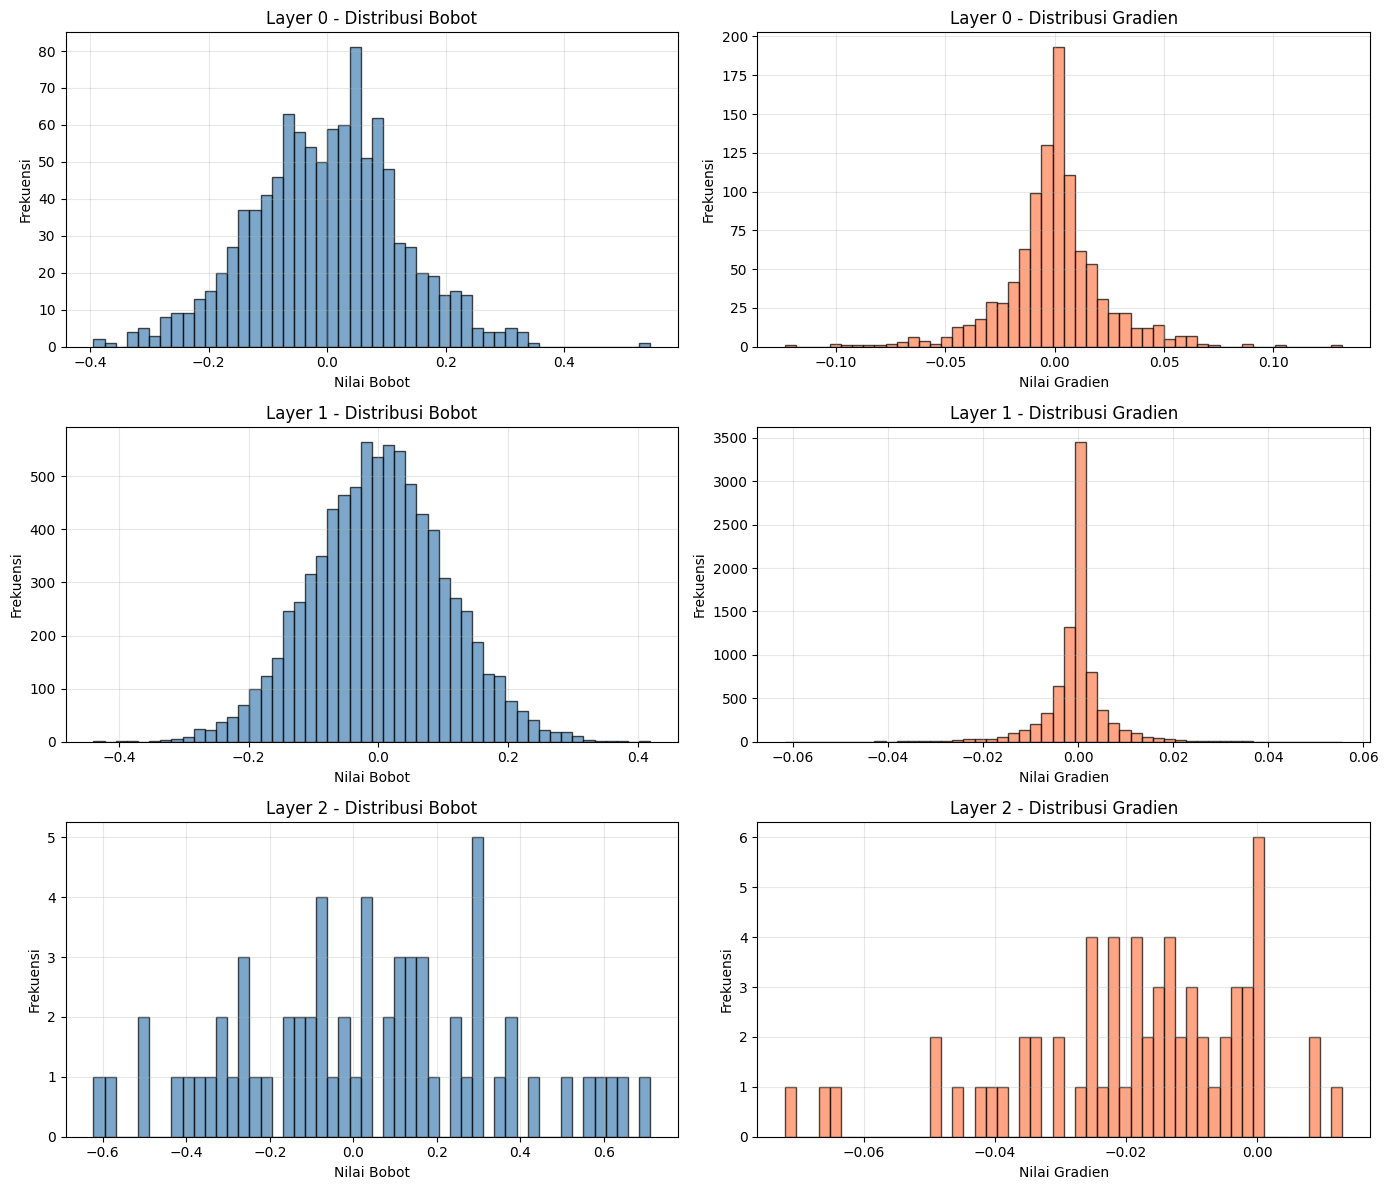


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Sigmoid
Test Accuracy: 0.7550

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003490 | Std: 0.126165
  Min: -0.432552 | Max: 0.500776
  Median: 0.000194

Layer 1:
  Shape: (128, 64)
  Mean: -0.000792 | Std: 0.104335
  Min: -0.443429 | Max: 0.447967
  Median: -0.000636

Layer 2:
  Shape: (64, 1)
  Mean: 0.014612 | Std: 0.337665
  Min: -0.536129 | Max: 0.860322
  Median: 0.021449

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000005 | Std: 0.003133
  Min: -0.017916 | Max: 0.018479
  Median: 0.000026
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

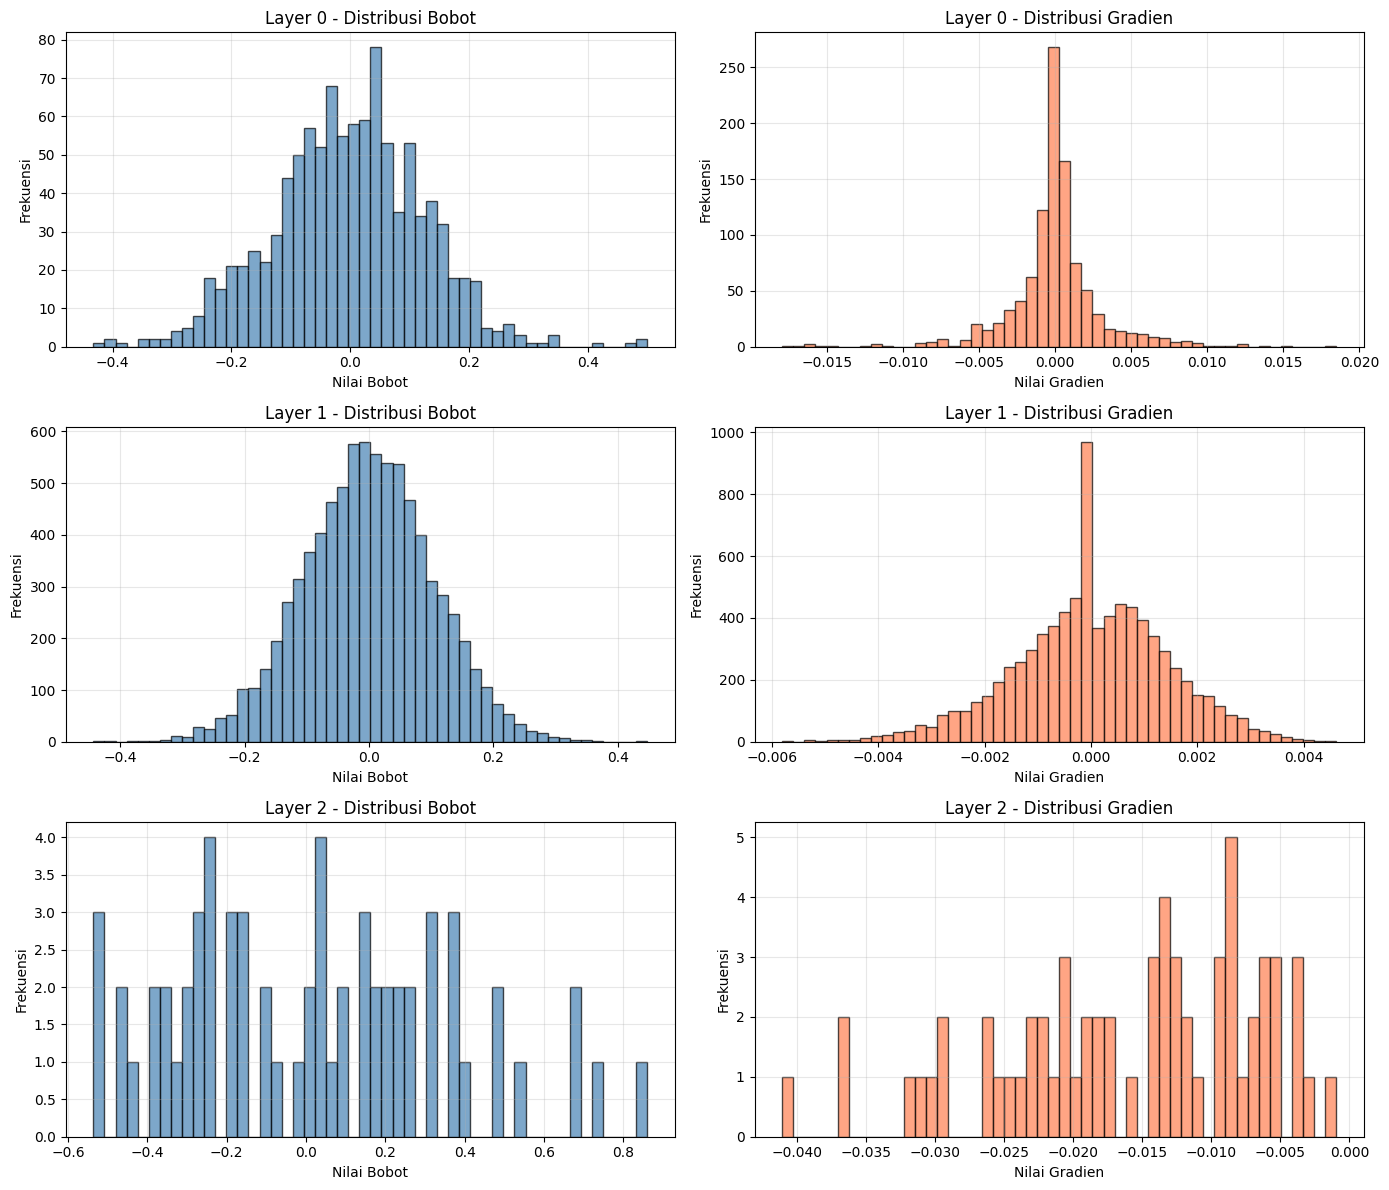


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Activation
Model: Act_Tanh
Test Accuracy: 0.7620

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.003067 | Std: 0.113426
  Min: -1.235166 | Max: 0.430828
  Median: 0.000692

Layer 1:
  Shape: (128, 64)
  Mean: -0.000902 | Std: 0.101860
  Min: -0.459538 | Max: 0.395554
  Median: -0.000715

Layer 2:
  Shape: (64, 1)
  Mean: -0.002382 | Std: 0.208273
  Min: -0.393375 | Max: 0.642108
  Median: 0.005457

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000457 | Std: 0.011160
  Min: -0.089984 | Max: 0.072841
  Median: 0.000251
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

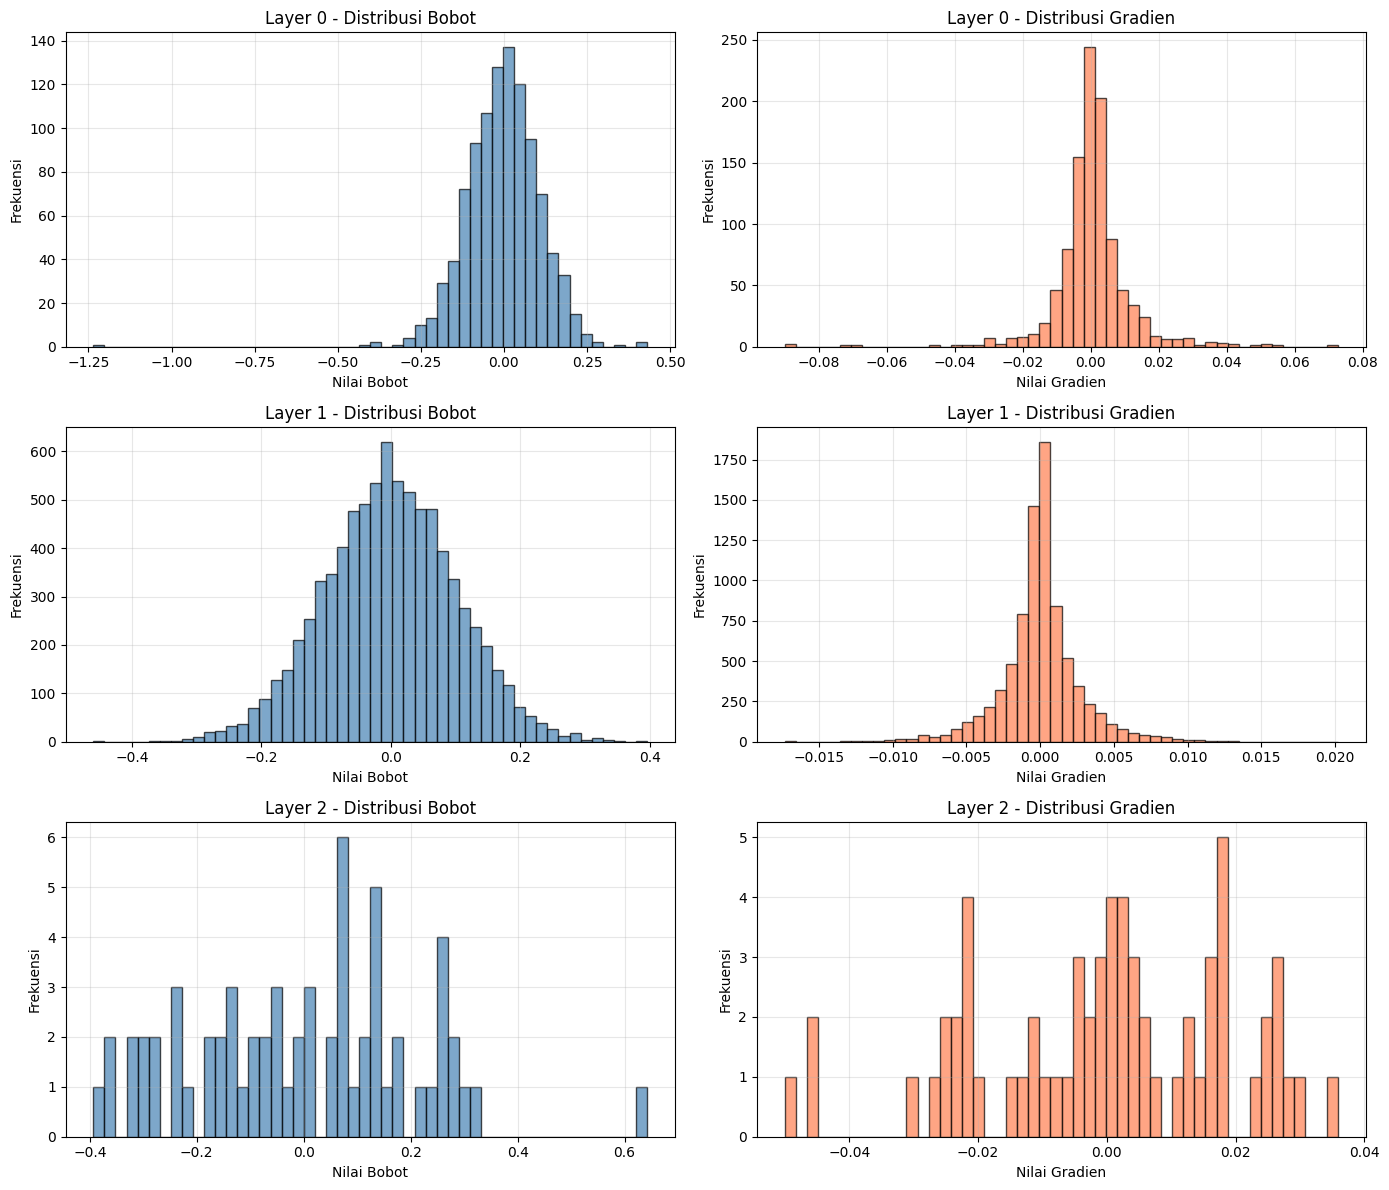

In [ ]:
analyze_results_distributions(
    activation_results,
    result_group_name='Activation',
)

### 4.1.3 Learning Rate

In [ ]:
learning_rates = {
    'LR_0.001': 0.001,
    'LR_0.01': 0.01,
    'LR_0.1': 0.1,
}

BASE_LR_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

lr_results = run_learning_rate_experiments(
    learning_rates=learning_rates,
    base_arch=BASE_LR_ARCH,
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init=INIT,
    regularization='l2',
    lambda_=1e-4,
    epochs=200,
    batch_size=32,
    verbose=20,
)


Running: LR_0.001 (lr=0.001)
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5077, Val Loss: 0.5025
Epoch 20/200, Train Loss: 0.4988, Val Loss: 0.4979
Epoch 30/200, Train Loss: 0.4947, Val Loss: 0.4961
Epoch 40/200, Train Loss: 0.4916, Val Loss: 0.4954
Epoch 50/200, Train Loss: 0.4897, Val Loss: 0.4960
Epoch 60/200, Train Loss: 0.4886, Val Loss: 0.4950
Epoch 70/200, Train Loss: 0.4870, Val Loss: 0.4967
Epoch 80/200, Train Loss: 0.4865, Val Loss: 0.4968
Epoch 90/200, Train Loss: 0.4853, Val Loss: 0.4963
Epoch 100/200, Train Loss: 0.4835, Val Loss: 0.4960
Epoch 110/200, Train Loss: 0.4826, Val Loss: 0.4970
Epoch 120/200, Train Loss: 0.4819, Val Loss: 0.4969
Epoch 130/200, Train Loss: 0.4804, Val Loss: 0.4970
Epoch 140/200, Train Loss: 0.4794, V

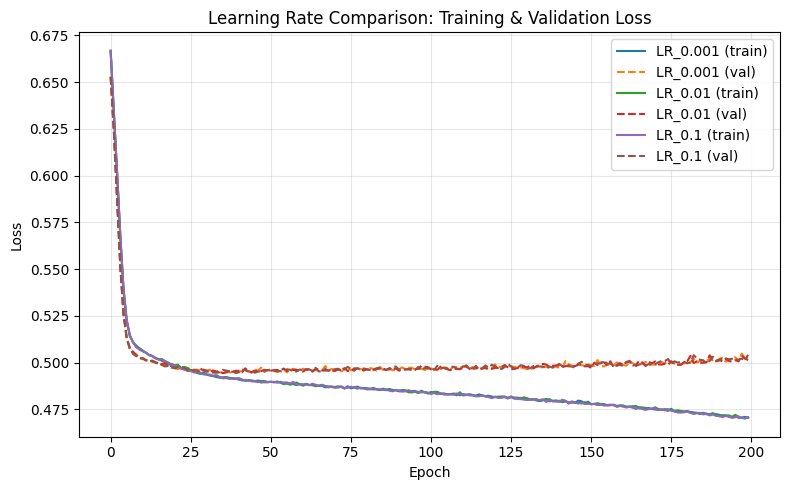

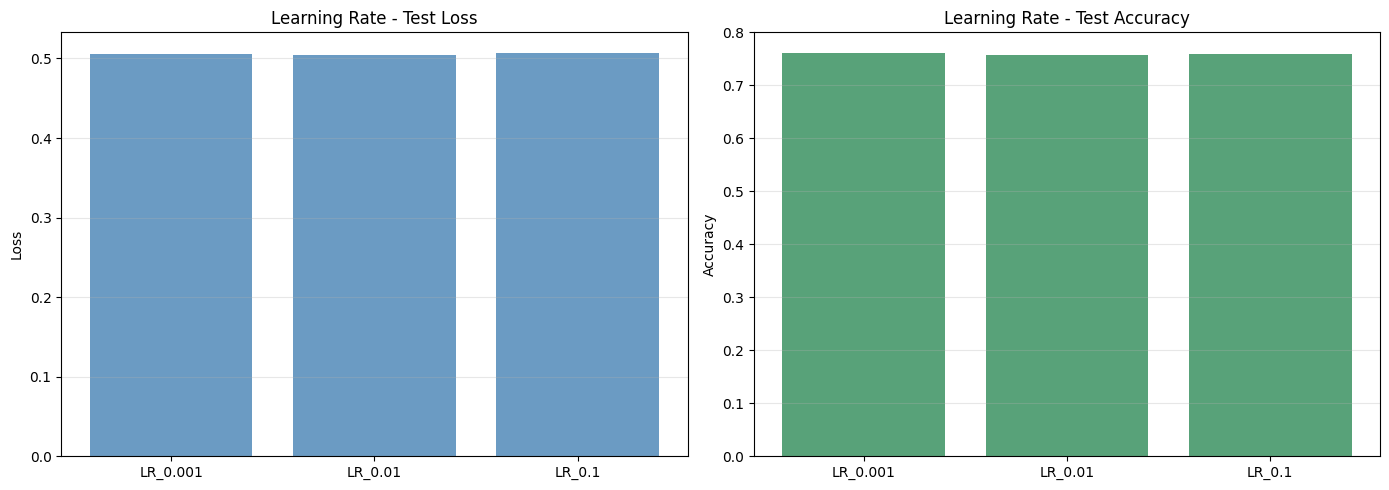

In [ ]:
plot_train_val_curves(
    lr_results,
    title='Learning Rate Comparison: Training & Validation Loss',
    zoom_start=50,
)

plot_prediction_bars(
    lr_results,
    title_prefix='Learning Rate',
)


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.001
Test Accuracy: 0.7620

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001886 | Std: 0.125178
  Min: -0.392880 | Max: 0.550266
  Median: 0.002820

Layer 1:
  Shape: (128, 64)
  Mean: 0.001668 | Std: 0.103936
  Min: -0.439447 | Max: 0.417221
  Median: 0.001919

Layer 2:
  Shape: (64, 1)
  Mean: 0.032583 | Std: 0.309374
  Min: -0.624486 | Max: 0.710923
  Median: 0.031072

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000537 | Std: 0.030107
  Min: -0.122209 | Max: 0.121118
  Median: 0.000062
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

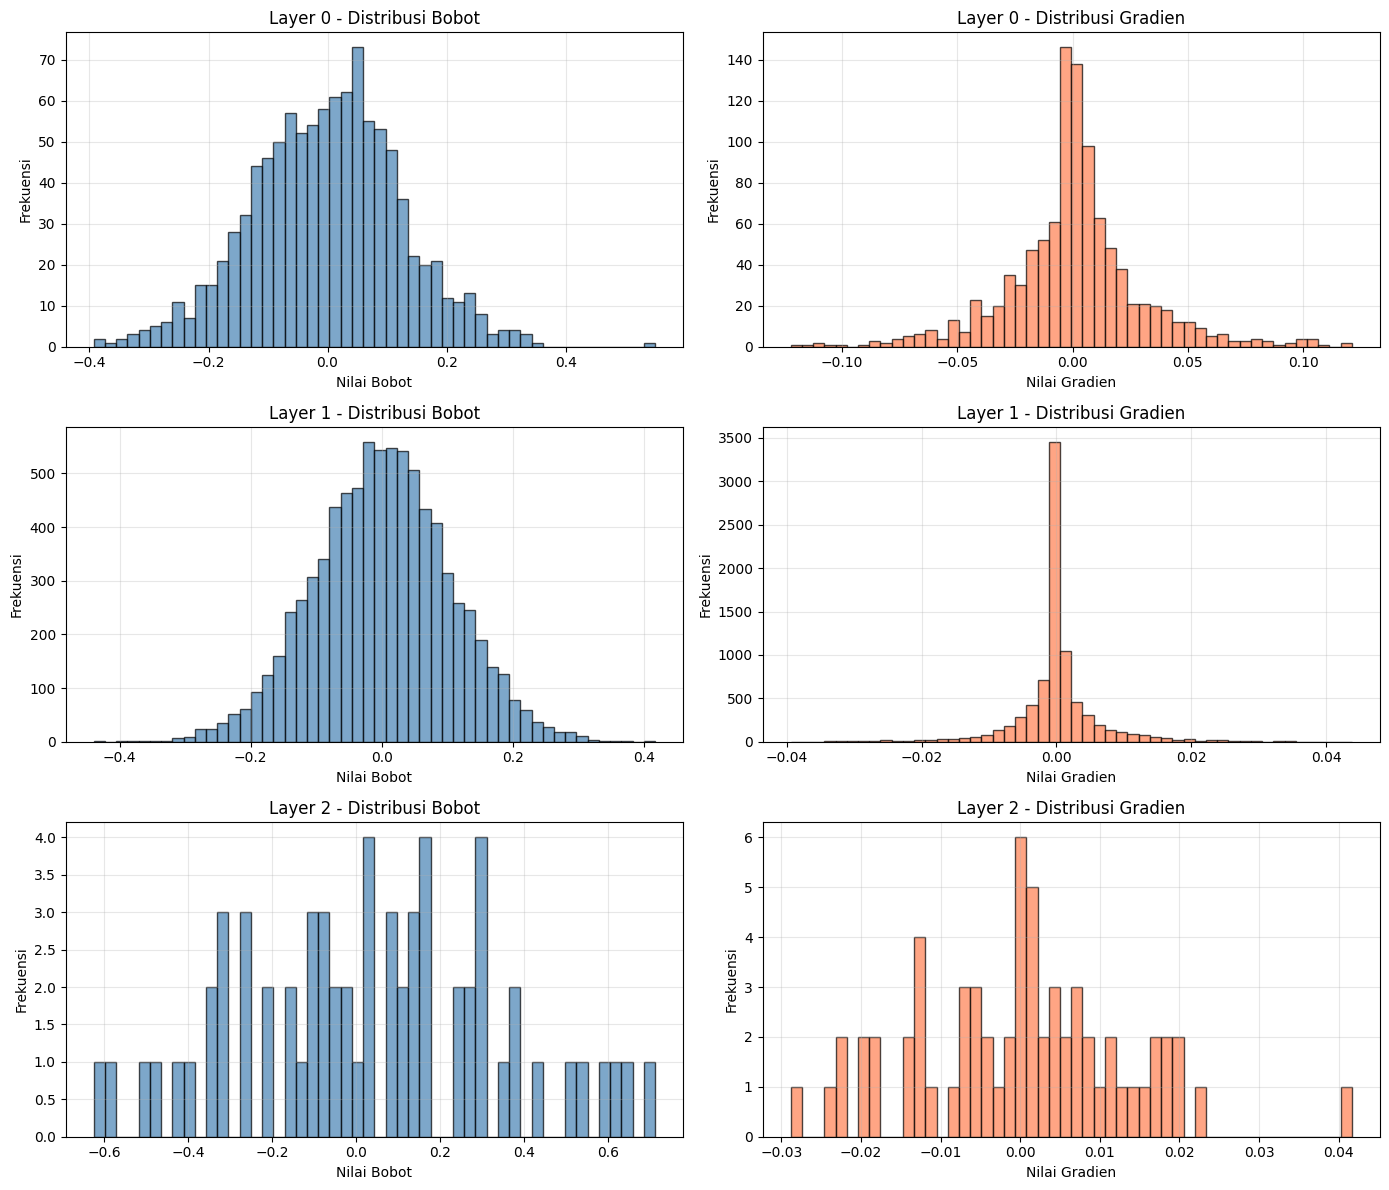


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.01
Test Accuracy: 0.7575

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.002044 | Std: 0.125392
  Min: -0.396296 | Max: 0.549945
  Median: -0.000562

Layer 1:
  Shape: (128, 64)
  Mean: 0.001491 | Std: 0.103956
  Min: -0.438806 | Max: 0.418997
  Median: 0.001597

Layer 2:
  Shape: (64, 1)
  Mean: 0.032839 | Std: 0.309868
  Min: -0.622538 | Max: 0.707387
  Median: 0.030427

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000485 | Std: 0.031491
  Min: -0.115829 | Max: 0.157952
  Median: -0.000007
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

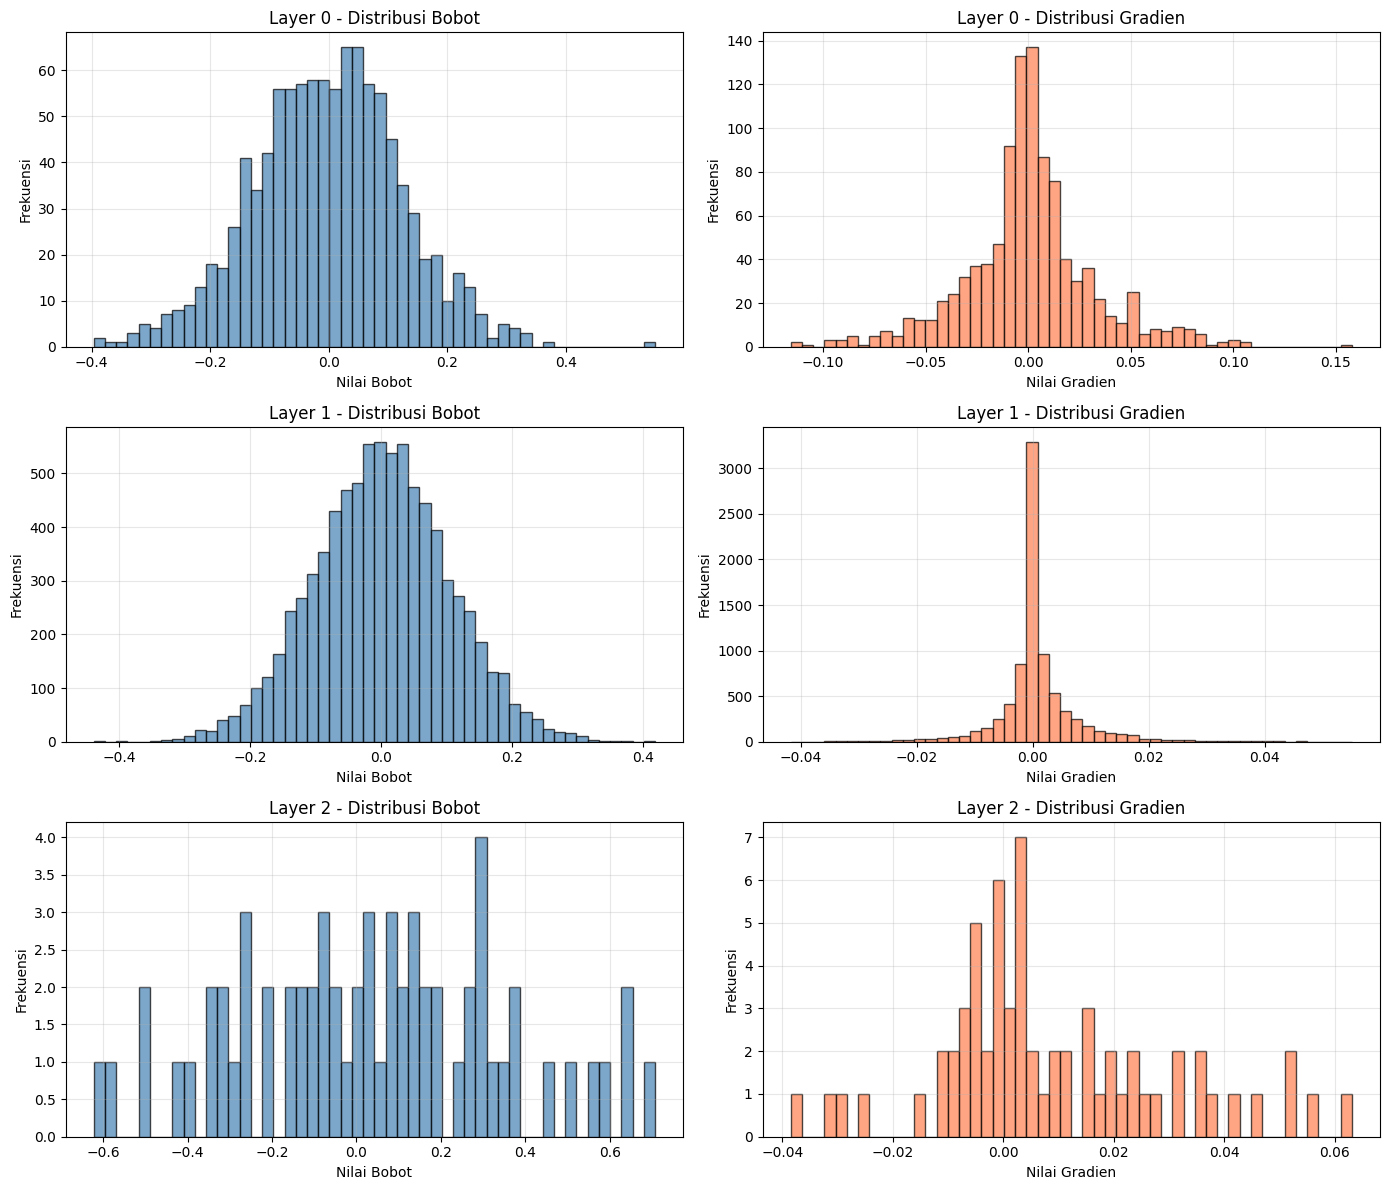


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Learning Rate
Model: LR_0.1
Test Accuracy: 0.7585

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001600 | Std: 0.125545
  Min: -0.395196 | Max: 0.543941
  Median: 0.002720

Layer 1:
  Shape: (128, 64)
  Mean: 0.001653 | Std: 0.103982
  Min: -0.438986 | Max: 0.417709
  Median: 0.002367

Layer 2:
  Shape: (64, 1)
  Mean: 0.033156 | Std: 0.311095
  Min: -0.611914 | Max: 0.723549
  Median: 0.032394

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001003 | Std: 0.038866
  Min: -0.166543 | Max: 0.155841
  Median: -0.000358
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

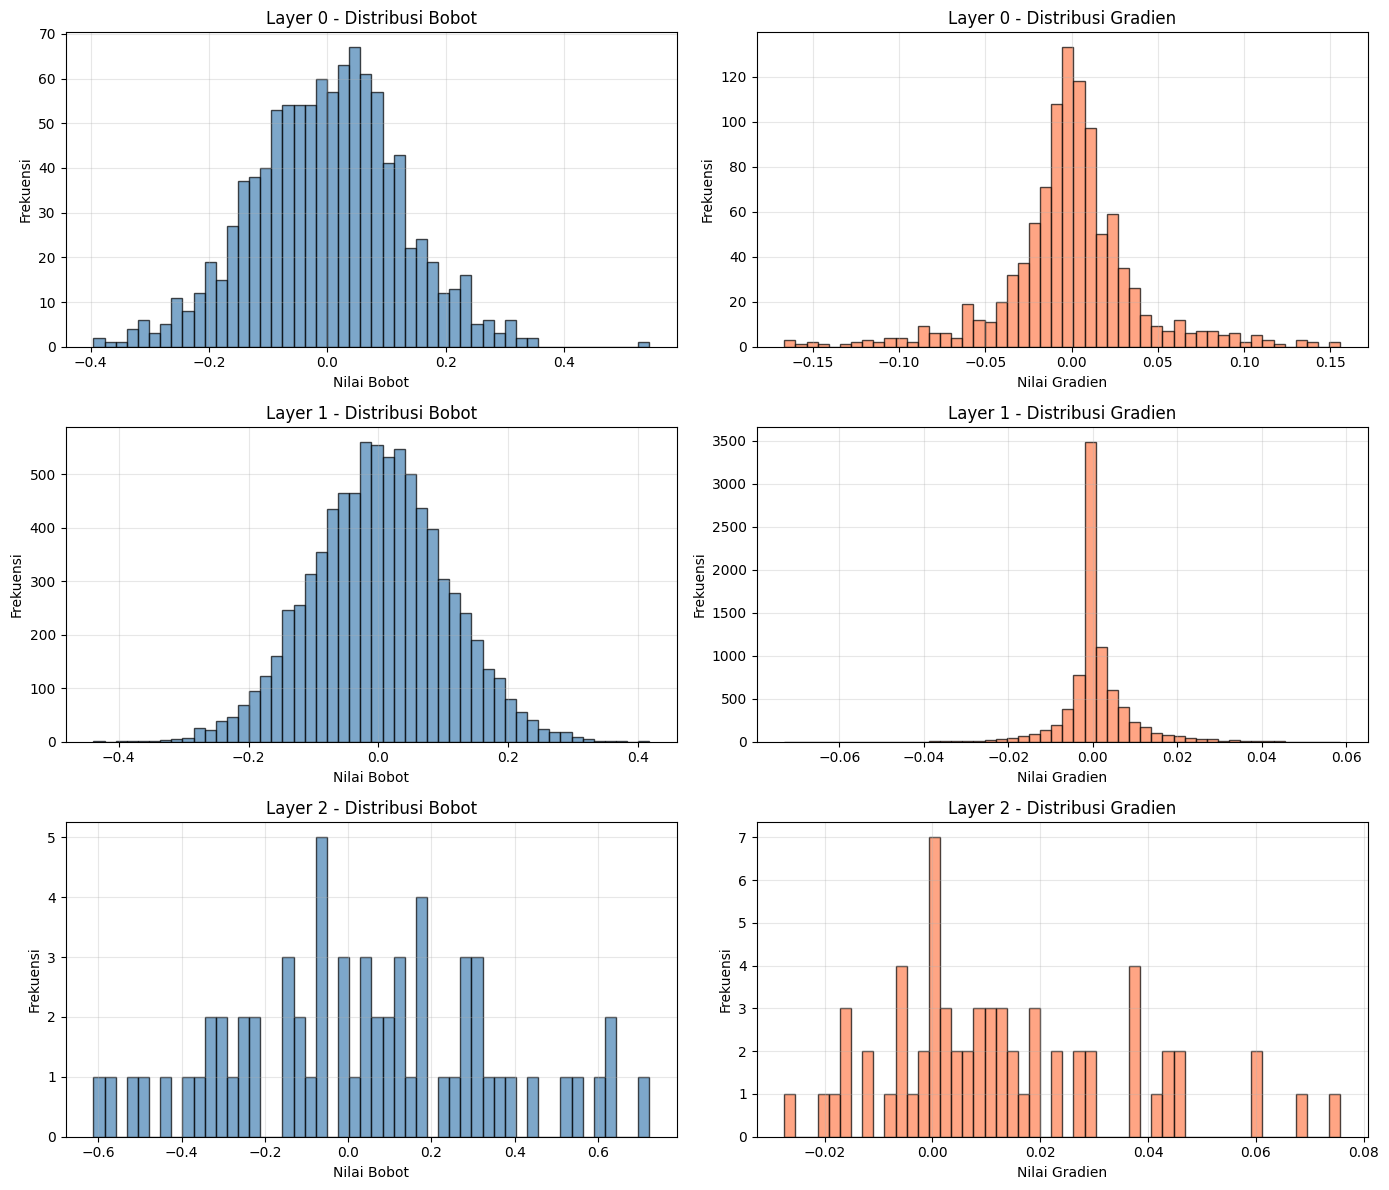

In [ ]:
analyze_results_distributions(
    lr_results,
    result_group_name='Learning Rate',
)

### 4.1.4 Pengaruh Inisialisasi Bobot

Memulai Eksperimen Inisialisasi Bobot...

Menguji Inisialisasi: ZERO

Running: zero
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

zero - Test Loss: 0.6678, Accuracy: 0.6125

Menguji Inisialisasi: RANDOM_UNIFORM

Running: random_uniform
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_uniform - Test Loss: 0.5038, Accuracy: 0.7590

Menguji Inisialisasi: RANDOM_NORMAL

Running: random_normal
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

random_normal - Test Loss: 0.5187, Accuracy: 0.7520


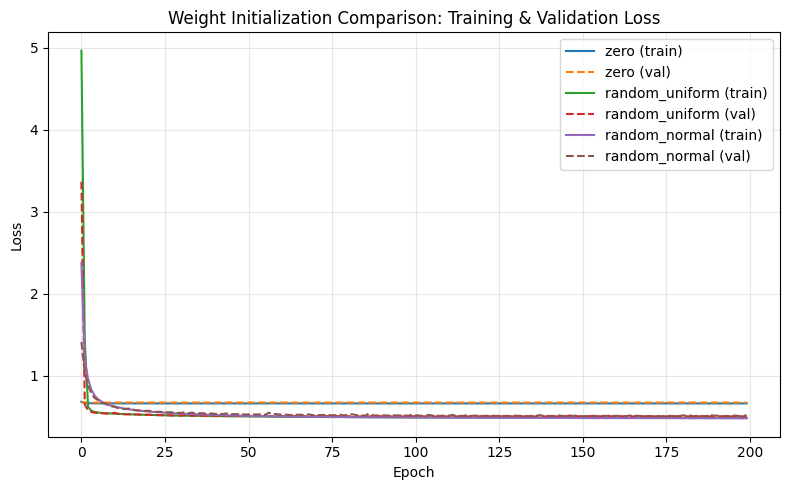

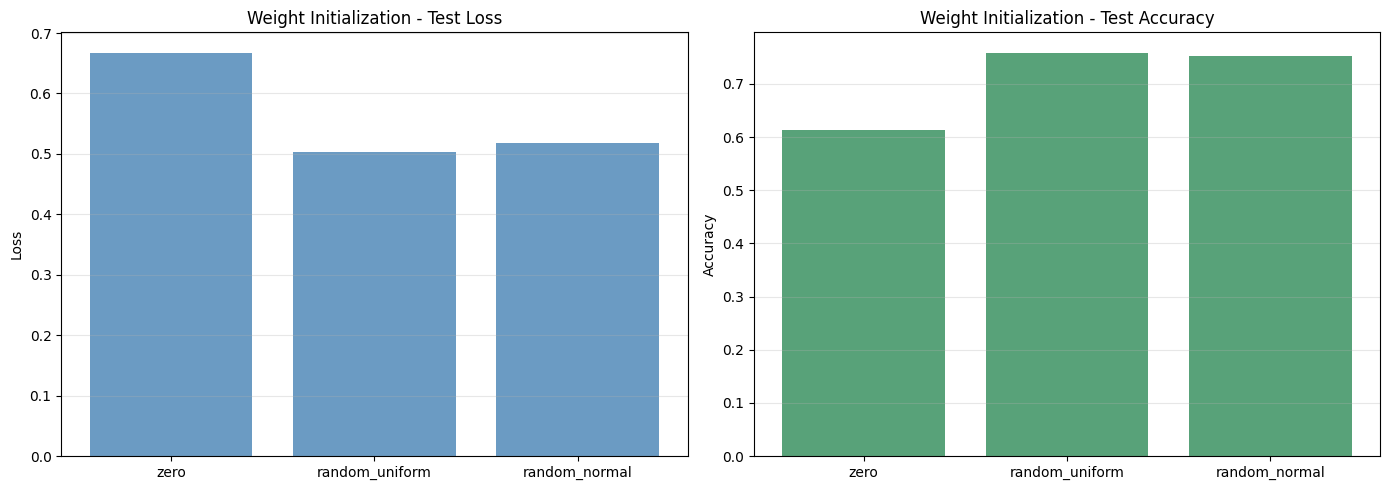

In [ ]:
print("Memulai Eksperimen Inisialisasi Bobot...")

init_methods = ['zero', 'random_uniform', 'random_normal']
init_results = {}

last_act = 'softmax' if TASK == 'multiclass' else 'sigmoid'
arch_for_init = [
    {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': last_act},
]

for method in init_methods:
    print(f"\n============================================================")
    print(f"Menguji Inisialisasi: {method.upper()}")
    print(f"============================================================")
    
    temp_exp = {method: arch_for_init}
    init_dict = {'init_method': method} 
    
    res = run_architecture_experiments(
        experiments=temp_exp,
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,        
        lr=0.01, 
        regularization='none',
        epochs=200,
        batch_size=32,
        verbose=0,             
    )
    init_results[method] = res[method]


plot_train_val_curves(init_results, title='Weight Initialization Comparison: Training & Validation Loss')

plot_prediction_bars(init_results, title_prefix='Weight Initialization')

## 4.2 Pengaruh Regularisasi


Running: Reg_None
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5076, Val Loss: 0.5030
Epoch 20/200, Train Loss: 0.4995, Val Loss: 0.4985
Epoch 30/200, Train Loss: 0.4941, Val Loss: 0.4961
Epoch 40/200, Train Loss: 0.4908, Val Loss: 0.4960
Epoch 50/200, Train Loss: 0.4896, Val Loss: 0.4955
Epoch 60/200, Train Loss: 0.4884, Val Loss: 0.4965
Epoch 70/200, Train Loss: 0.4870, Val Loss: 0.4955
Epoch 80/200, Train Loss: 0.4862, Val Loss: 0.4969
Epoch 90/200, Train Loss: 0.4849, Val Loss: 0.4960
Epoch 100/200, Train Loss: 0.4847, Val Loss: 0.4962
Epoch 110/200, Train Loss: 0.4830, Val Loss: 0.4970
Epoch 120/200, Train Loss: 0.4818, Val Loss: 0.4976
Epoch 130/200, Train Loss: 0.4807, Val Loss: 0.4974
Epoch 140/200, Train Loss: 0.4799, Val Loss: 0.

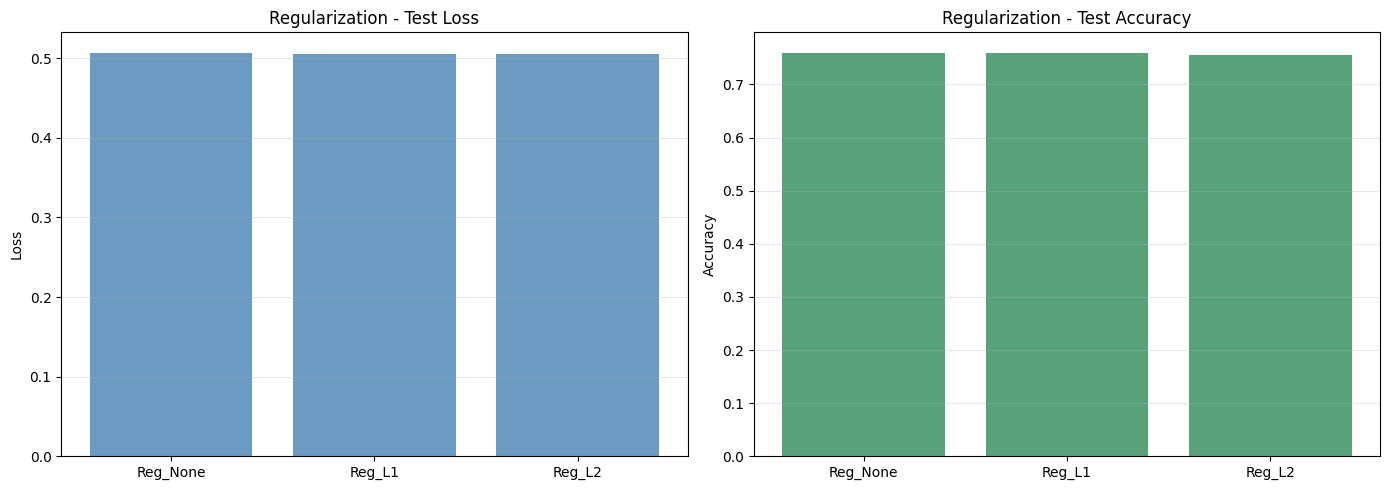

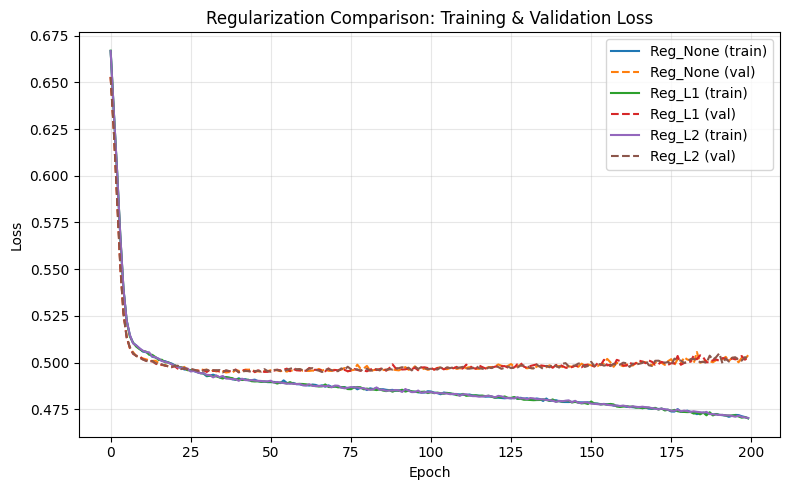


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_None
Test Accuracy: 0.7600

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001802 | Std: 0.125178
  Min: -0.397072 | Max: 0.543654
  Median: 0.000323

Layer 1:
  Shape: (128, 64)
  Mean: 0.001579 | Std: 0.103928
  Min: -0.437965 | Max: 0.414880
  Median: 0.001329

Layer 2:
  Shape: (64, 1)
  Mean: 0.033000 | Std: 0.308741
  Min: -0.618449 | Max: 0.706070
  Median: 0.033208

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000117 | Std: 0.021949
  Min: -0.111843 | Max: 0.103216
  Median: 0.000123
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (1

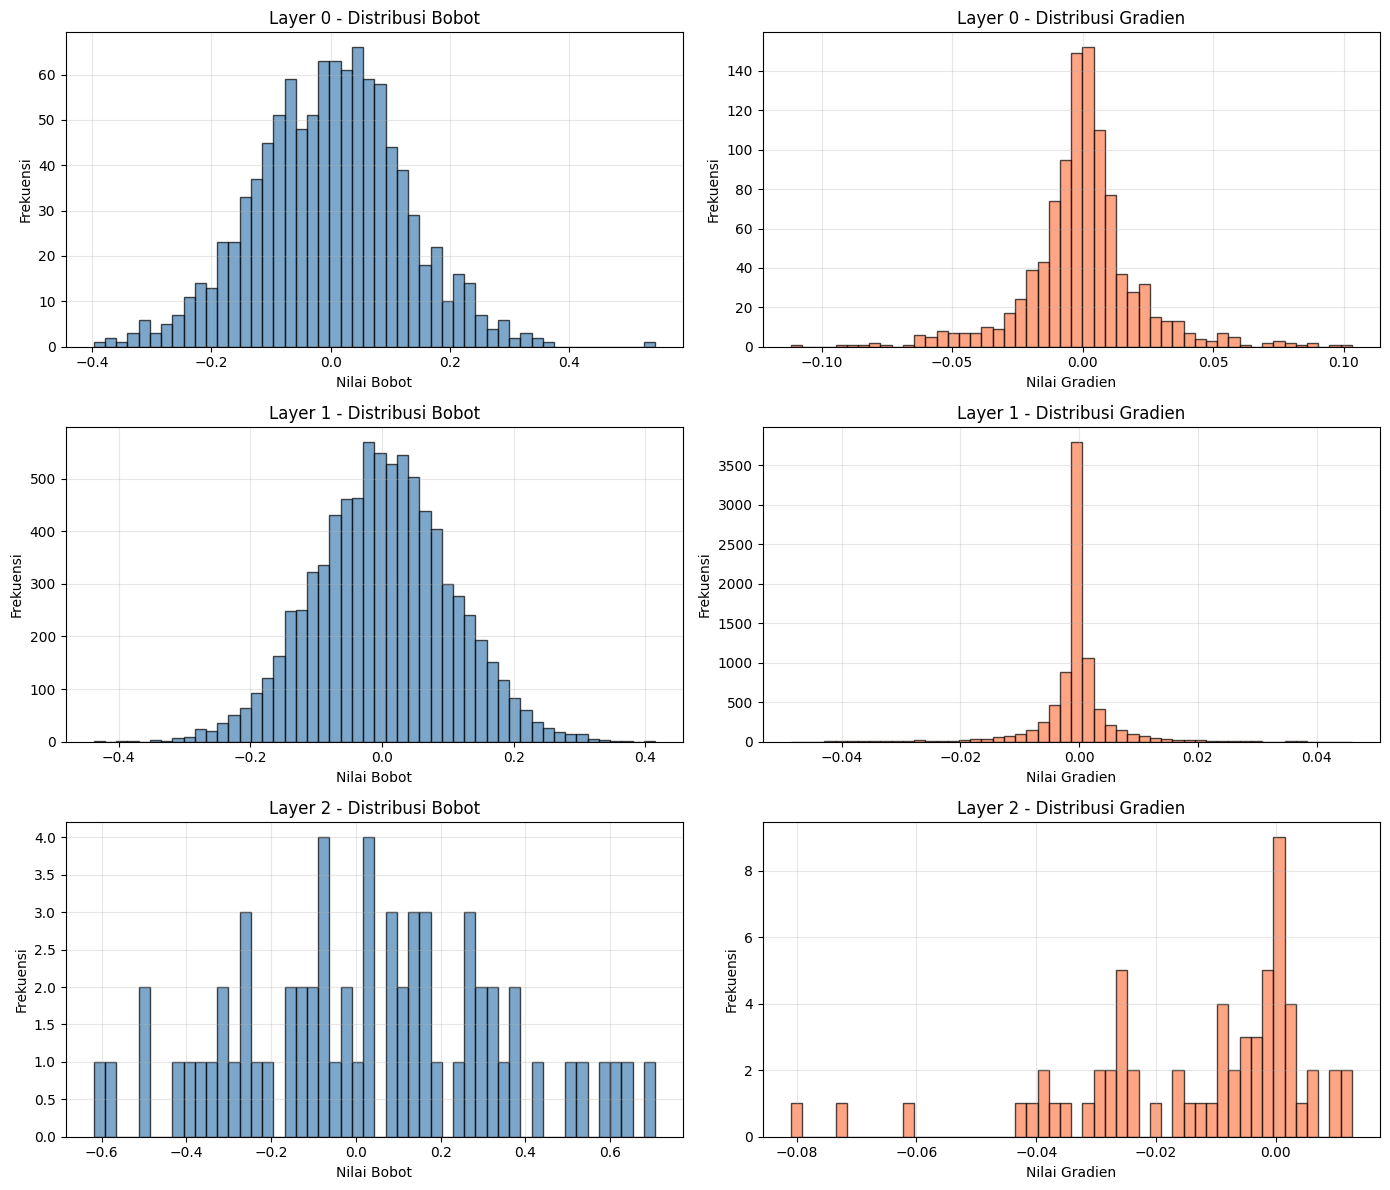


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L1
Test Accuracy: 0.7585

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001713 | Std: 0.125398
  Min: -0.401250 | Max: 0.551844
  Median: 0.001340

Layer 1:
  Shape: (128, 64)
  Mean: 0.001584 | Std: 0.103967
  Min: -0.438959 | Max: 0.417216
  Median: 0.001729

Layer 2:
  Shape: (64, 1)
  Mean: 0.032273 | Std: 0.310511
  Min: -0.624623 | Max: 0.707735
  Median: 0.034369

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: 0.000736 | Std: 0.032124
  Min: -0.100471 | Max: 0.113284
  Median: -0.000644
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (128

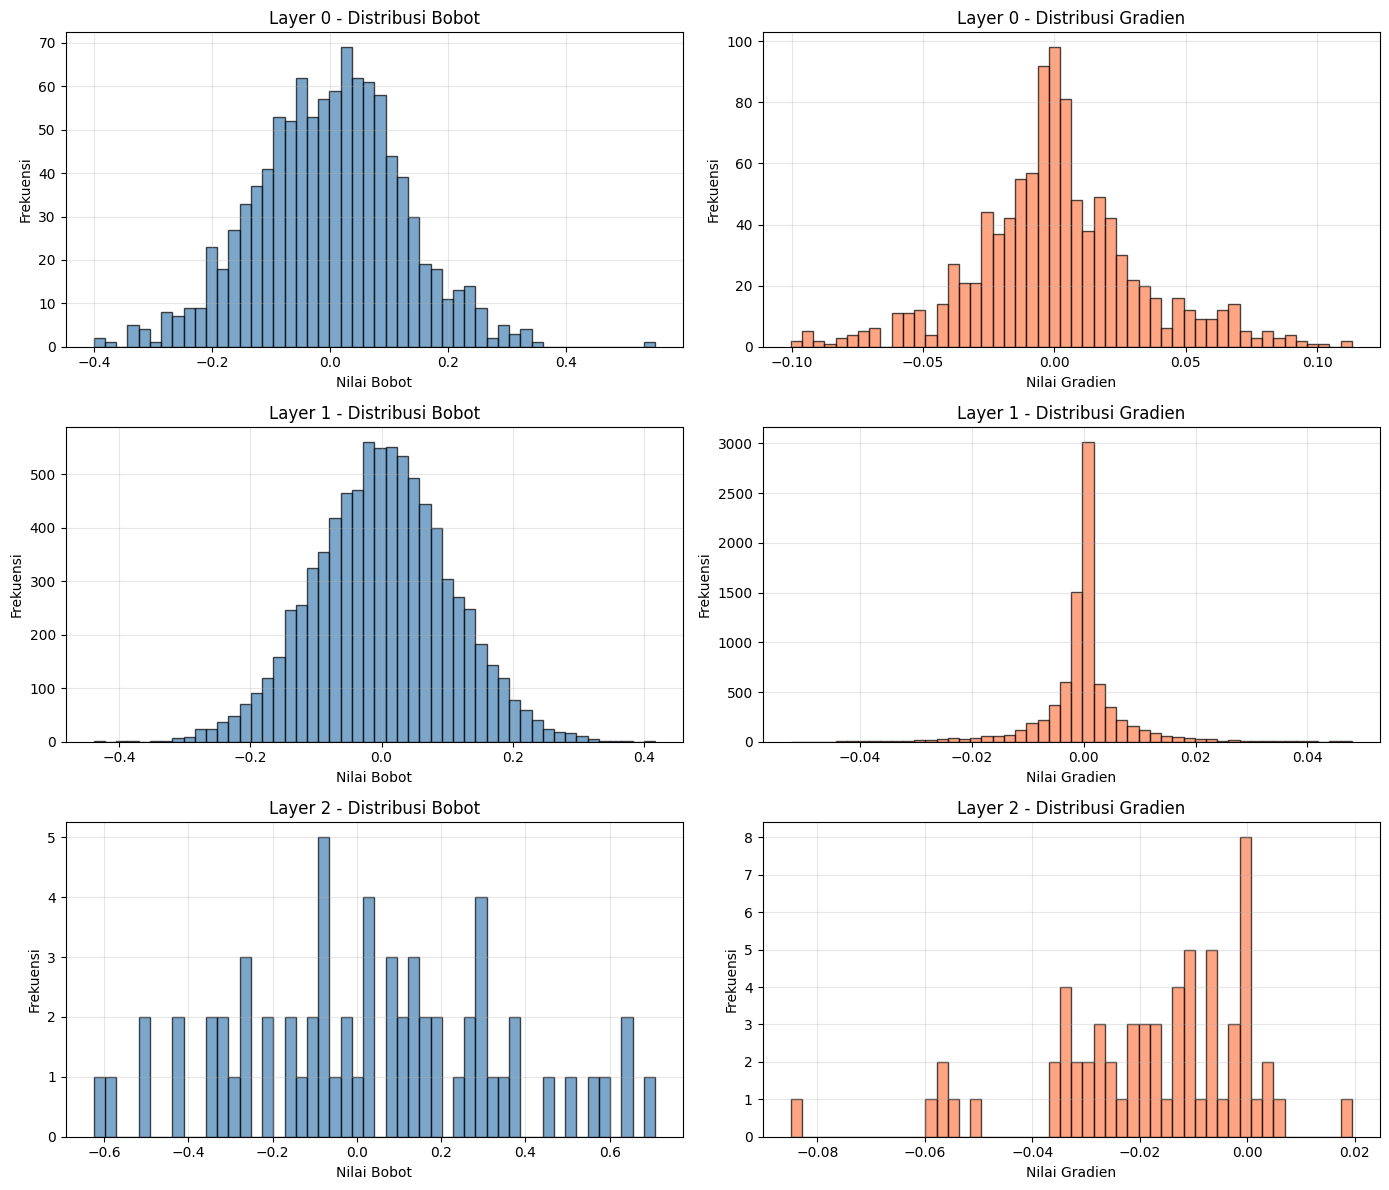


ANALISIS DISTRIBUSI BOBOT DAN GRADIEN PER LAYER

Sumber hasil: Regularization
Model: Reg_L2
Test Accuracy: 0.7560

--------------------------------------------------------------------------------
STATISTIK BOBOT PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.001671 | Std: 0.125160
  Min: -0.400728 | Max: 0.559494
  Median: 0.000584

Layer 1:
  Shape: (128, 64)
  Mean: 0.001491 | Std: 0.103914
  Min: -0.439192 | Max: 0.415876
  Median: 0.001732

Layer 2:
  Shape: (64, 1)
  Mean: 0.032161 | Std: 0.308278
  Min: -0.621828 | Max: 0.702016
  Median: 0.037124

--------------------------------------------------------------------------------
STATISTIK GRADIEN PER LAYER:
--------------------------------------------------------------------------------

Layer 0:
  Shape: (8, 128)
  Mean: -0.000379 | Std: 0.019262
  Min: -0.098592 | Max: 0.095882
  Median: -0.000843
  % Zero Gradients: 0.00%

Layer 1:
  Shape: (12

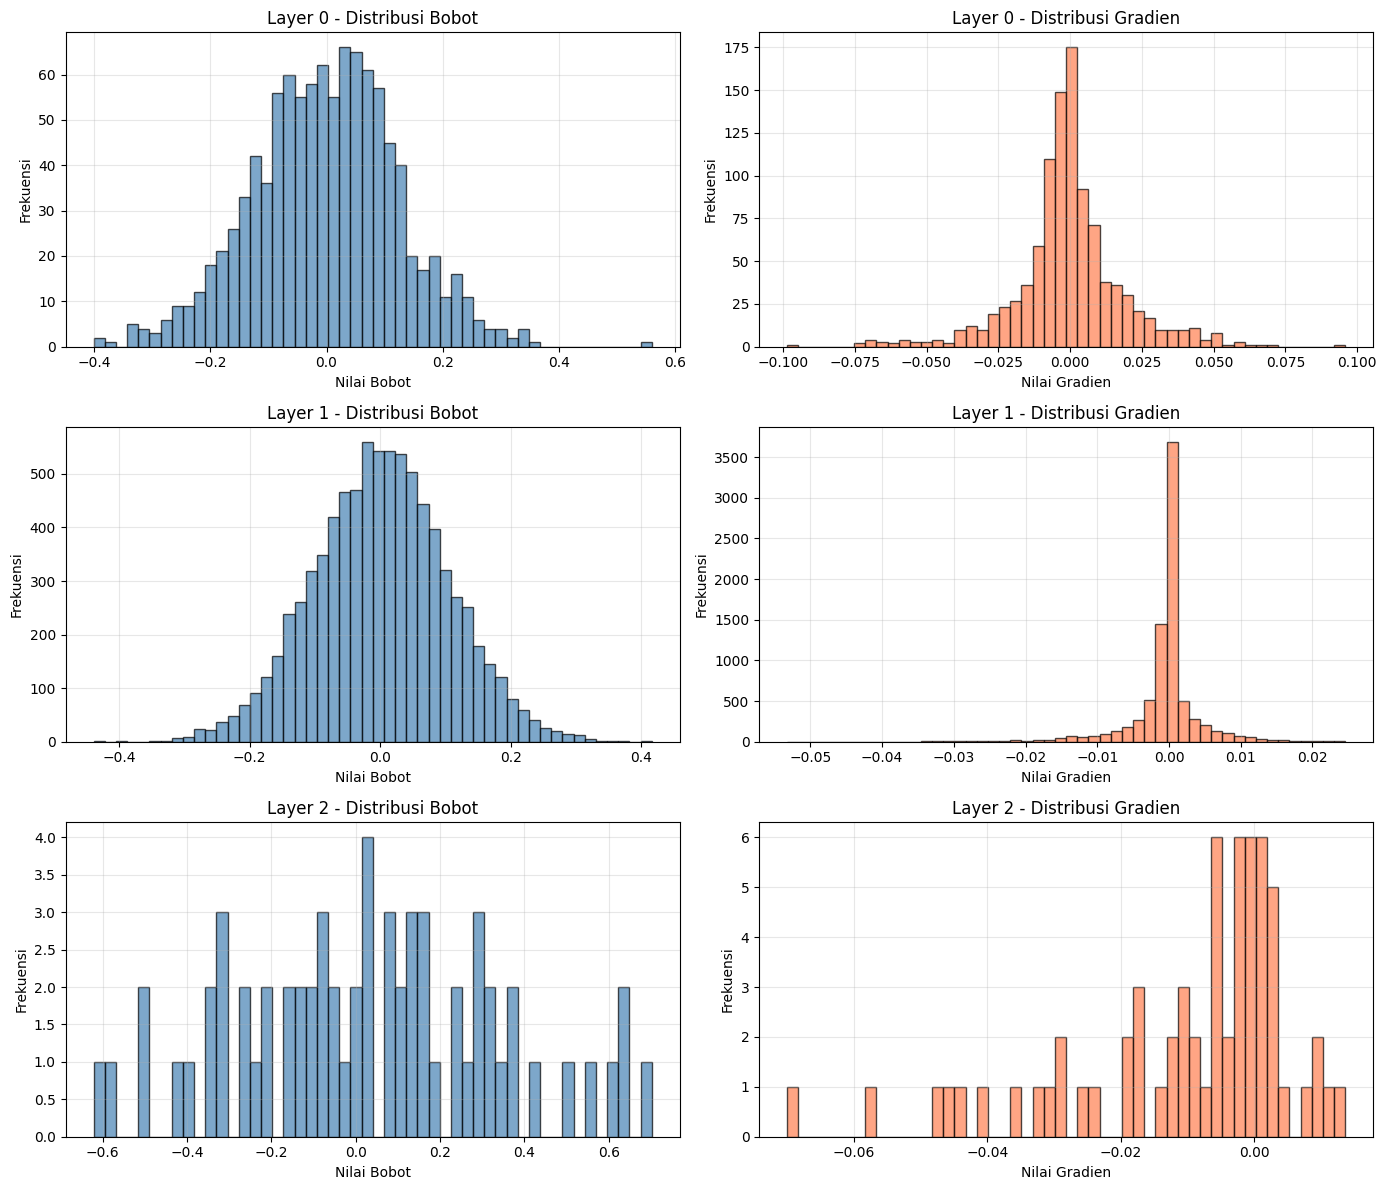

In [ ]:
regularization_settings = {
    'Reg_None': {'regularization': 'none', 'lambda_': 0.0},
    'Reg_L1': {'regularization': 'l1', 'lambda_': 1e-4},
    'Reg_L2': {'regularization': 'l2', 'lambda_': 1e-4},
}

REG_ARCH = [
    {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
    {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
    {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

INIT = {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}}

regularization_results = {}

for exp_name, cfg in regularization_settings.items():
    one_exp = {exp_name: REG_ARCH}

    res = run_architecture_experiments(
        experiments=one_exp,
        task=TASK,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        init=INIT,
        lr=0.01,
        regularization=cfg['regularization'],
        lambda_=cfg['lambda_'],
        epochs=200,
        batch_size=32,
        verbose=20,
    )

    for k, v in res.items():
        v['regularization'] = cfg['regularization']
        v['lambda_'] = cfg['lambda_']

    regularization_results.update(res)

reg_summary = pd.DataFrame([
    {
        'experiment': name,
        'regularization': result['regularization'],
        'lambda': result['lambda_'],
        'test_loss': result['test_loss'],
        'test_accuracy': result['test_accuracy'],
    }
    for name, result in regularization_results.items()
]).sort_values(by='test_accuracy', ascending=False)

print('\nRINGKASAN HASIL AKHIR PREDIKSI (REGULARISASI)')
print(reg_summary.to_string(index=False))

plot_prediction_bars(
    regularization_results,
    title_prefix='Regularization',
)

plot_train_val_curves(
    regularization_results,
    title='Regularization Comparison: Training & Validation Loss',
    zoom_start=50,
)

analyze_results_distributions(
    regularization_results,
    result_group_name='Regularization',
)

## 4.3 Eksperimen Bonus: Inisialisasi Bobot & Fungsi Aktivasi Baru
Di sini kita akan mencoba metode inisialisasi Xavier & He beserta fungsi aktivasi ELU dan Leaky ReLU.


Running: Random_Normal
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Random_Normal - Test Loss: 0.4993, Accuracy: 0.7620

Running: Xavier_Glorot
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

Xavier_Glorot - Test Loss: 0.5013, Accuracy: 0.7580

Running: He_Init
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473

He_Init - Test Loss: 0.518

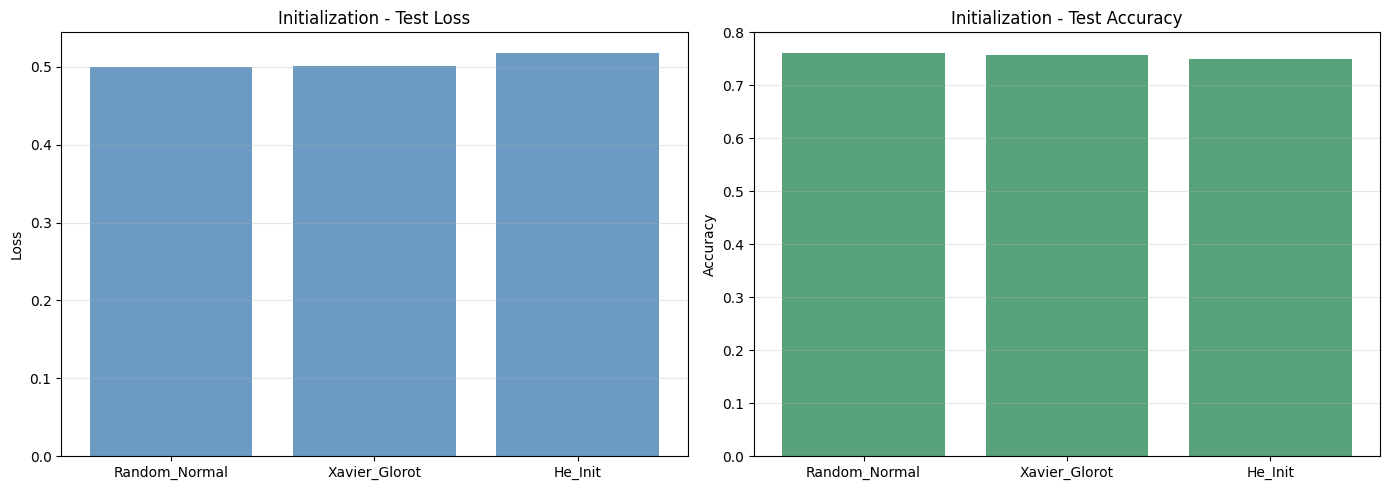

In [ ]:
# Uji Inisialisasi: Random Normal vs Xavier vs He
init_experiments = {
    'Random_Normal': {'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': 42}},
    'Xavier_Glorot': {'init_method': 'xavier', 'init_params': {'seed': 42}},
    'He_Init':       {'init_method': 'he', 'init_params': {'seed': 42}},
}

init_results = {}
for init_name, init_dict in init_experiments.items():
    res = run_architecture_experiments(
        experiments={init_name: [
            {'n_in': n_features, 'n_out': 128, 'activation': 'relu'},
            {'n_in': 128, 'n_out': 64, 'activation': 'relu'},
            {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
        ]},
        task=TASK,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        init=init_dict,
        lr=0.01,
        epochs=100,
        batch_size=32,
        verbose=0,
    )
    init_results.update(res)

plot_prediction_bars(init_results, title_prefix='Initialization')



Running: ReLU
  Layer 1: DenseLayer(8 → 64, activation=ReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

ReLU - Test Loss: 0.4988, Accuracy: 0.7545

Running: Leaky_ReLU
  Layer 1: DenseLayer(8 → 64, activation=LeakyReLU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

Leaky_ReLU - Test Loss: 0.4991, Accuracy: 0.7545

Running: ELU
  Layer 1: DenseLayer(8 → 64, activation=ELU)  [576 params]
  Layer 2: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 641

ELU - Test Loss: 0.4980, Accuracy: 0.7565


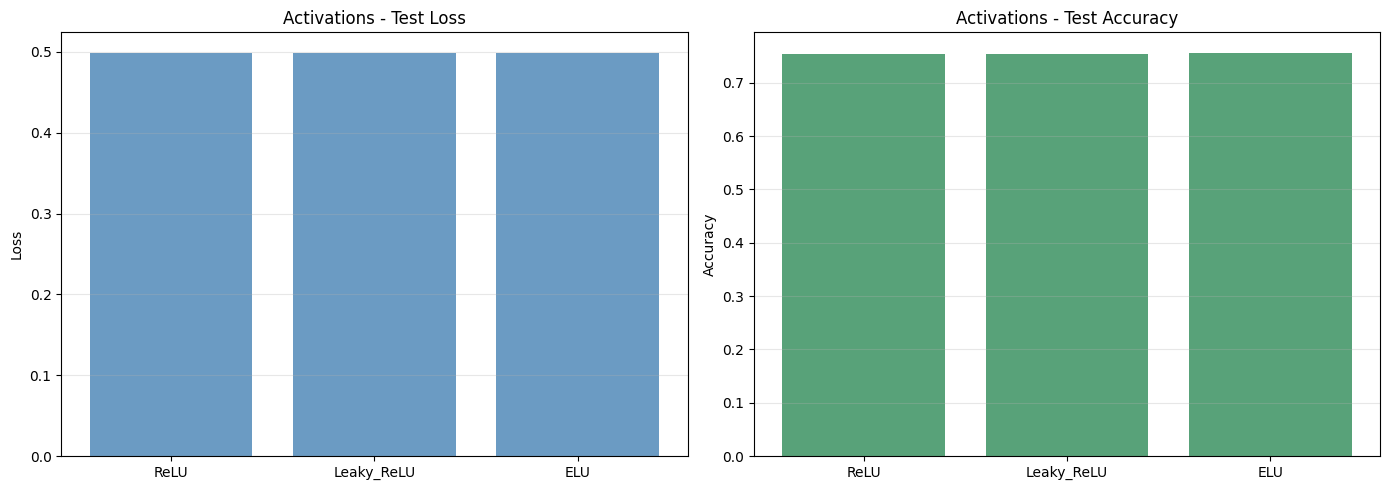

In [ ]:
# Uji Aktivasi: ReLU vs Leaky ReLU vs ELU
act_experiments = {
    'ReLU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
    'Leaky_ReLU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'leaky_relu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
    'ELU': [
        {'n_in': n_features, 'n_out': 64, 'activation': 'elu'},
        {'n_in': 64, 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'}
    ],
}

act_results = run_architecture_experiments(
    experiments=act_experiments,
    task=TASK,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    init={'init_method': 'he', 'init_params': {'seed': 42}},
    lr=0.01,
    epochs=100,
    batch_size=32,
    verbose=0,
)

plot_prediction_bars(act_results, title_prefix='Activations')


## 4.4 Uji Perbandingan

In [ ]:
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Hyperparameter
SHARED_HPARAMS = {
    'hidden_dims': (128, 64),
    'lr': 0.01,
    'batch_size': 32,
    'epochs': 200,
    'lambda_': 1e-4,
    'seed': 42,
}

# 1) Train FFNN from scratch
ffnn_arch = [
    {'n_in': n_features, 'n_out': SHARED_HPARAMS['hidden_dims'][0], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][0], 'n_out': SHARED_HPARAMS['hidden_dims'][1], 'activation': 'relu'},
    {'n_in': SHARED_HPARAMS['hidden_dims'][1], 'n_out': n_out, 'activation': 'softmax' if TASK == 'multiclass' else 'sigmoid'},
]

ffnn_result = run_architecture_experiments(
    experiments={'FFNN_Scratch': ffnn_arch},
    task=TASK,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    init={'init_method': 'random_normal', 'init_params': {'mean': 0, 'std': 0.1, 'seed': SHARED_HPARAMS['seed']}},
    lr=SHARED_HPARAMS['lr'],
    regularization='l2',
    lambda_=SHARED_HPARAMS['lambda_'],
    epochs=SHARED_HPARAMS['epochs'],
    batch_size=SHARED_HPARAMS['batch_size'],
    verbose=20,
)['FFNN_Scratch']

ffnn_model = ffnn_result['model']
ffnn_prob = ffnn_model.predict(X_test)
if TASK == 'binary':
    y_true_cls = y_test.astype(int).ravel()
    y_pred_ffnn = (ffnn_prob >= 0.5).astype(int).ravel()
else:
    y_true_cls = np.argmax(y_test, axis=1)
    y_pred_ffnn = np.argmax(ffnn_prob, axis=1)

if TASK == 'binary':
    y_train_sklearn = y_train.ravel().astype(int)
else:
    y_train_sklearn = np.argmax(y_train, axis=1)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=SHARED_HPARAMS['hidden_dims'],
    activation='relu',
    solver='sgd',
    alpha=SHARED_HPARAMS['lambda_'],
    learning_rate_init=SHARED_HPARAMS['lr'],
    batch_size=SHARED_HPARAMS['batch_size'],
    max_iter=SHARED_HPARAMS['epochs'],
    random_state=SHARED_HPARAMS['seed'],
)

sk_mlp.fit(X_train, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)

comparison_df = pd.DataFrame([
    {
        'Model': 'FFNN From Scratch',
        'Test Accuracy': np.mean(y_pred_ffnn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_ffnn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_ffnn != y_true_cls)),
    },
    {
        'Model': 'sklearn MLPClassifier',
        'Test Accuracy': np.mean(y_pred_sklearn == y_true_cls),
        'Prediksi Benar': int(np.sum(y_pred_sklearn == y_true_cls)),
        'Prediksi Salah': int(np.sum(y_pred_sklearn != y_true_cls)),
    },
]).sort_values(by='Test Accuracy', ascending=False)

print('Perbandingan hasil akhir prediksi (test set):')
display(comparison_df)


Running: FFNN_Scratch
  Layer 1: DenseLayer(8 → 128, activation=ReLU)  [1,152 params]
  Layer 2: DenseLayer(128 → 64, activation=ReLU)  [8,256 params]
  Layer 3: DenseLayer(64 → 1, activation=Sigmoid)  [65 params]
----------------------------------------------------
  Total params: 9,473
Epoch 10/200, Train Loss: 0.5079, Val Loss: 0.5025
Epoch 20/200, Train Loss: 0.4991, Val Loss: 0.4977
Epoch 30/200, Train Loss: 0.4940, Val Loss: 0.4953
Epoch 40/200, Train Loss: 0.4917, Val Loss: 0.4950
Epoch 50/200, Train Loss: 0.4898, Val Loss: 0.4956
Epoch 60/200, Train Loss: 0.4883, Val Loss: 0.4956
Epoch 70/200, Train Loss: 0.4873, Val Loss: 0.4955
Epoch 80/200, Train Loss: 0.4860, Val Loss: 0.4960
Epoch 90/200, Train Loss: 0.4852, Val Loss: 0.4959
Epoch 100/200, Train Loss: 0.4837, Val Loss: 0.4970
Epoch 110/200, Train Loss: 0.4826, Val Loss: 0.4969
Epoch 120/200, Train Loss: 0.4814, Val Loss: 0.4977
Epoch 130/200, Train Loss: 0.4807, Val Loss: 0.4982
Epoch 140/200, Train Loss: 0.4795, Val Loss

,Model,Test Accuracy,Prediksi Benar,Prediksi Salah
0,FFNN From Scratch,0.7615,1523,477
1,sklearn MLPClassifier,0.6765,1353,647


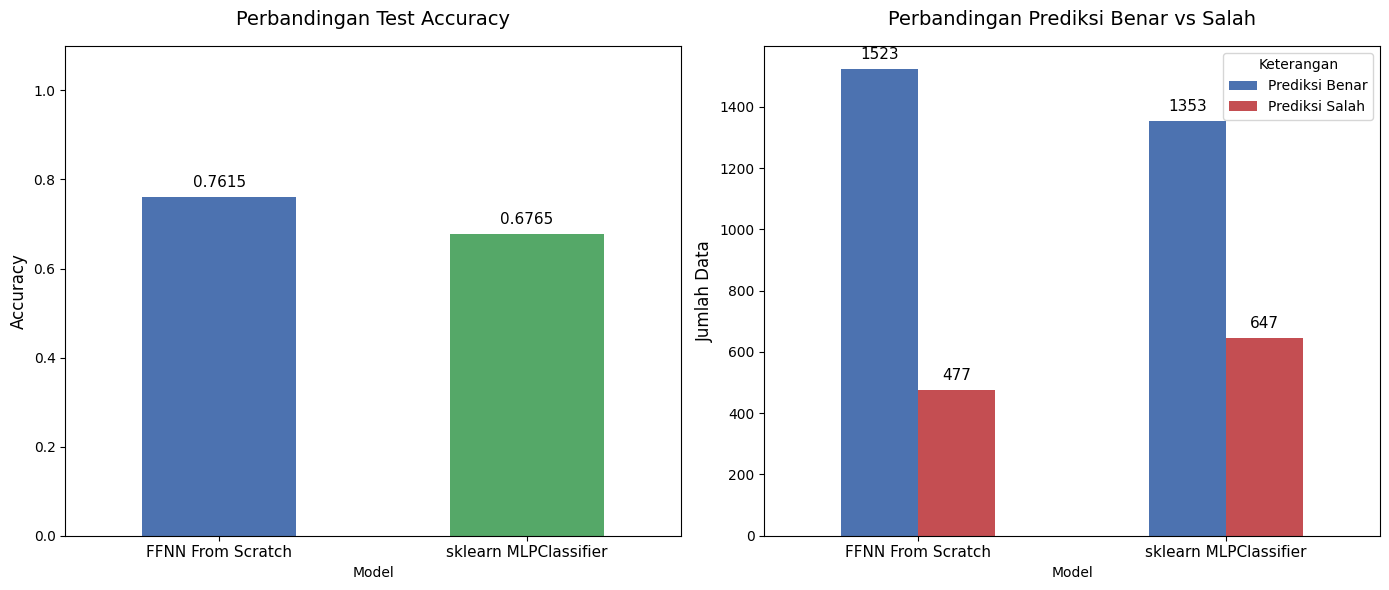

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comparison_df.plot(
    x='Model', 
    y='Test Accuracy', 
    kind='bar', 
    ax=axes[0], 
    color=['#4C72B0', '#55A868'], 
    legend=False
)
axes[0].set_title('Perbandingan Test Accuracy', fontsize=14, pad=15)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.1) 
axes[0].tick_params(axis='x', rotation=0, labelsize=11)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

comparison_df.plot(
    x='Model', 
    y=['Prediksi Benar', 'Prediksi Salah'], 
    kind='bar', 
    ax=axes[1], 
    color=['#4C72B0', '#C44E52']
)
axes[1].set_title('Perbandingan Prediksi Benar vs Salah', fontsize=14, pad=15)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].tick_params(axis='x', rotation=0, labelsize=11)
axes[1].legend(title='Keterangan')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{int(height)}", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Kesimpulan
Berdasarkan rangkaian eksperimen yang telah dilakukan, dapat disimpulkan beberapa hal sebagai berikut:

1. **Implementasi Autograd Berhasil**: FFNN yang dibangun dari nol menggunakan mesin autograd terbukti mampu belajar dan menurunkan loss secara konsisten, sebanding dengan library standar seperti scikit-learn.
2. **Pengaruh Inisialisasi**: Metode inisialisasi **Xavier** dan **He** memberikan stabilitas awal yang lebih baik dibandingkan random normal biasa, membantu model konvergen lebih cepat.
3. **Fungsi Aktivasi**: Aktivasi **ReLU**, **Leaky ReLU**, dan **ELU** memberikan performa yang kompetitif untuk data placement ini. Leaky ReLU dan ELU membantu menghindari masalah *neuron mati* pada network yang lebih dalam.
4. **Performa Model**: Model FFNN mampu memprediksi status placement mahasiswa dengan akurasi yang cukup baik, menunjukkan bahwa fitur-fitur seperti CGPA, Aptitude Score, dan Internship memiliki korelasi kuat terhadap target.

## 6. Bonus: Analisis Perbandingan Adam Optimizer vs Gradient Descent
Pada bagian ini, kita akan melatih base model yang sama pada dataset menggunakana dua optimizer yang berbeda:
1. **SGD (Standard Gradient Descent)**
2. **Adam (Adaptive Moment Estimation)**

Tujuannya adalah melihat perbedaan kecepatan konvergensi dari pergerakan *training loss* dan *validation loss* tiap epoch.

In [ ]:
import time
from ffnn import FFNN

# Konfigurasi Model (Arsitektur Base)
# Kita akan pakai konfigurasi yang wajar dan mudah terlihat lambat kalo pakai GD biasa
adam_base_config = [
    {"n_in": X_train.shape[1], "n_out": 16, "activation": "relu", "init_method": "he"},
    {"n_in": 16, "n_out": 8, "activation": "relu", "init_method": "he"},
    {"n_in": 8, "n_out": n_out, "activation": "softmax" if TASK == "multiclass" else "sigmoid", "init_method": "xavier"}
]

# Parameter Training
base_epochs = 30
base_batch_size = 32
base_lr = 0.001 
loss_name = "cce" if TASK == "multiclass" else "bce"

# 1. Training menggunakan Optimizer SGD Biasa
print("==== Training Model dengan Optimizer: SGD ===")
model_sgd = FFNN(adam_base_config)
model_sgd.compile(loss=loss_name, optimizer="sgd")

start_time = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=0.01, # LR SGD biasanya perlu sedikit lebih besar biar adil
    optimizer="sgd", 
    verbose=1
)
sgd_time = time.time() - start_time
print(f"Waktu Training SGD: {sgd_time:.2f} detik\n")

# 2. Training menggunakan Optimizer Adam
print("==== Training Model dengan Optimizer: Adam ===")
# Build ulang dari awal biar bobot awal acaknya fair
model_adam = FFNN(adam_base_config)
model_adam.compile(loss=loss_name, optimizer="adam")

start_time = time.time()
history_adam = model_adam.fit(
    X_train, y_train, 
    epochs=base_epochs, batch_size=base_batch_size, 
    X_val=X_test, y_val=y_test, 
    lr=base_lr, # Adam sangat efektif di 0.001
    optimizer="adam", 
    verbose=1
)
adam_time = time.time() - start_time
print(f"Waktu Training Adam: {adam_time:.2f} detik\n")

In [ ]:
# Mari kita plot perbandingan grafiknya
plt.figure(figsize=(14, 6))

epochs_range = range(1, base_epochs + 1)

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_sgd['train_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['train_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Training Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_sgd['val_loss'], label='SGD (lr=0.01)', color='blue', linestyle='--')
plt.plot(epochs_range, history_adam['val_loss'], label='Adam (lr=0.001)', color='red', linestyle='-')
plt.title('Perbandingan Validation Loss: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Analisis Hasil
Dari grafik perbandingan kecepatan konvergensi di atas, dapat dilihat bahwa:
1. **Adam** sanggup menurunkan _training loss_ dengan sangat curam (konvergen cepat) di _epoch-epoch_ awal, meski hanya memakai *learning rate* 0.001. 
2. **SGD standar** dengan *learning rate* lebih besar (0.01) cenderung turun lebih pelan dan membutuhkan waktu (lebih banyak *epoch*) untuk mendapatkan batas konvergensi yang serupa dengan Adam.
3. Adam unggul berkat konsep kombinasi **momen pertama (momentum)** dan **momen kedua (RMSProp)**. Momentum membantu meluncur melewati lembah _loss_, sedangkan adaptasi RMSprop menakar besaran _learning rate_ di tiap parameter untuk menjaga kelincahannya menembus topologi _loss landscape_ yang tidak rata.